# Import libraries

In [ ]:
import pandas as pd
import glob
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict

#Import data

In [ ]:
# Find all your pvoutput CSV files
files = glob.glob("pvoutput_data_*.csv")

# Combine them
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f" Combined shape: {df.shape}")

 Combined shape: (105120, 8)


In [ ]:
print(len(files))
print

12


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

# Data Manipulation

In [ ]:
df.head()

,Date,Time,Energy,Power,Temperature,Datetime,is_imputed,imputation_method
0,01/04/25,12:00AM,0.0,0.0,7.0,2025-04-01 00:00:00,False,original
1,01/04/25,12:05AM,0.0,0.0,7.0,2025-04-01 00:05:00,False,original
2,01/04/25,12:10AM,0.0,0.0,7.0,2025-04-01 00:10:00,False,original
3,01/04/25,12:15AM,0.0,0.0,7.0,2025-04-01 00:15:00,False,original
4,01/04/25,12:20AM,0.0,0.0,7.0,2025-04-01 00:20:00,False,original


In [ ]:
# Sort by the Datetime column (already in proper datetime format)
df_sorted = df.sort_values('Datetime')

# Reset index after sorting
df_sorted = df_sorted.reset_index(drop=True)

print("Data sorted chronologically!")
print(df_sorted[['Date', 'Time', 'Datetime']].head())

Data sorted chronologically!
       Date     Time             Datetime
0  01/05/24  12:00AM  2024-05-01 00:00:00
1  01/05/24  12:05AM  2024-05-01 00:05:00
2  01/05/24  12:10AM  2024-05-01 00:10:00
3  01/05/24  12:15AM  2024-05-01 00:15:00
4  01/05/24  12:20AM  2024-05-01 00:20:00


In [ ]:
df_sorted.head()

,Date,Time,Energy,Power,Temperature,Datetime,is_imputed,imputation_method
0,01/05/24,12:00AM,0.0,0.0,15.2,2024-05-01 00:00:00,False,measured
1,01/05/24,12:05AM,0.0,0.0,15.2,2024-05-01 00:05:00,False,measured
2,01/05/24,12:10AM,0.0,0.0,15.2,2024-05-01 00:10:00,False,measured
3,01/05/24,12:15AM,0.0,0.0,15.2,2024-05-01 00:15:00,False,measured
4,01/05/24,12:20AM,0.0,0.0,15.2,2024-05-01 00:20:00,False,measured


In [ ]:
print(df_sorted[['Date', 'Time', 'Datetime']].tail())

            Date     Time             Datetime
105115  30/04/25  11:35PM  2025-04-30 23:35:00
105116  30/04/25  11:40PM  2025-04-30 23:40:00
105117  30/04/25  11:45PM  2025-04-30 23:45:00
105118  30/04/25  11:50PM  2025-04-30 23:50:00
105119  30/04/25  11:55PM  2025-04-30 23:55:00


In [ ]:
# Generate expected timestamps for 5 minutes
start_date = pd.Timestamp('2024-05-01 00:00:00')
end_date = pd.Timestamp('2025-04-30 23:55:00')

expected_timestamps = []
current_date = start_date
while current_date <= end_date:
  expected_timestamps.append(current_date)
  current_date += pd.Timedelta(minutes=5)

print(f"Expected number of timestamps for a year: {len(expected_timestamps)}")

Expected number of timestamps for a year: 105120


In [ ]:
# Check for missing timestamps
actual_timestamps = set(df_sorted['Datetime'].unique())
expected_timestamps_set = set(expected_timestamps)
missing_timestamps = expected_timestamps_set - actual_timestamps

print(f"Number of missing timestamps: {len(missing_timestamps)}")
completeness = ((len(expected_timestamps) - len(missing_timestamps)) / len(expected_timestamps)) * 100
print(f"Data completeness: {completeness:.2f}%")

Number of missing timestamps: 105120
Data completeness: 0.00%


In [ ]:
print(df_sorted.dtypes)

Date                  object
Time                  object
Energy               float64
Power                float64
Temperature          float64
Datetime              object
is_imputed              bool
imputation_method     object
dtype: object


In [ ]:
# First, ensure both are in the same format
# Convert dataframe datetime to pandas datetime if not already
df_sorted['Datetime'] = pd.to_datetime(df_sorted['Datetime'])

# Generate expected timestamps
start_date = pd.Timestamp('2024-05-01 00:00:00')
end_date = pd.Timestamp('2025-04-30 23:55:00')

expected_timestamps = pd.date_range(start=start_date, end=end_date, freq='5min')
print(f"Expected number of timestamps: {len(expected_timestamps)}")

# Get actual timestamps from dataframe
actual_timestamps = pd.to_datetime(df_sorted['Datetime'])
print(f"Actual number of timestamps: {len(actual_timestamps)}")
print(f"Unique timestamps in data: {len(actual_timestamps.unique())}")

# Find missing timestamps
missing_timestamps = expected_timestamps.difference(actual_timestamps)
print(f"\nNumber of missing timestamps: {len(missing_timestamps)}")

# Calculate completeness
completeness = ((len(expected_timestamps) - len(missing_timestamps)) / len(expected_timestamps)) * 100
print(f"Data completeness: {completeness:.2f}%")


# Check date range of your actual data
print(f"\nActual data range:")
print(f"  Start: {df_sorted['Datetime'].min()}")
print(f"  End: {df_sorted['Datetime'].max()}")

# Check for duplicates
duplicates = df_sorted['Datetime'].duplicated().sum()
print(f"\nNumber of duplicate timestamps: {duplicates}")

Expected number of timestamps: 105120
Actual number of timestamps: 105120
Unique timestamps in data: 105120

Number of missing timestamps: 0
Data completeness: 100.00%

Actual data range:
  Start: 2024-05-01 00:00:00
  End: 2025-04-30 23:55:00

Number of duplicate timestamps: 0


In [ ]:
df_solecast = pd.read_csv("solcast_data.csv")
df_solecast.drop("period", axis=1, inplace=True)
df_solecast['Datetime'] = pd.to_datetime(df_solecast['period_end'])

In [ ]:
df_solecast.head()

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,cloud_opacity,dewpoint_temp,dhi,dni,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,zenith,period_end,Datetime
0,17,-19,0,0,0,0,76.4,11.5,0,0,0,0,70.7,138,2.7,136,2024-04-01T00:05:00+00:00,2024-04-01 00:05:00+00:00
1,17,-21,0,0,0,0,78.0,11.4,0,0,0,0,70.2,139,2.7,136,2024-04-01T00:10:00+00:00,2024-04-01 00:10:00+00:00
2,17,-23,0,0,0,0,78.8,11.3,0,0,0,0,69.7,139,2.7,136,2024-04-01T00:15:00+00:00,2024-04-01 00:15:00+00:00
3,17,-24,0,0,0,0,76.4,11.2,0,0,0,0,69.2,140,2.7,135,2024-04-01T00:20:00+00:00,2024-04-01 00:20:00+00:00
4,17,-26,0,0,0,0,76.4,11.1,0,0,0,0,68.7,140,2.7,135,2024-04-01T00:25:00+00:00,2024-04-01 00:25:00+00:00


In [ ]:
df_solecast.tail()

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,cloud_opacity,dewpoint_temp,dhi,dni,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,zenith,period_end,Datetime
113755,11,-11,0,0,0,0,0.0,7.9,0,0,0,0,81.6,40,1.6,127,2025-04-30T23:40:00+00:00,2025-04-30 23:40:00+00:00
113756,11,-12,0,0,0,0,0.0,7.8,0,0,0,0,81.5,39,1.6,127,2025-04-30T23:45:00+00:00,2025-04-30 23:45:00+00:00
113757,11,-14,0,0,0,0,0.0,7.8,0,0,0,0,81.4,38,1.7,127,2025-04-30T23:50:00+00:00,2025-04-30 23:50:00+00:00
113758,11,-15,0,0,0,0,0.0,7.7,0,0,0,0,81.3,37,1.7,127,2025-04-30T23:55:00+00:00,2025-04-30 23:55:00+00:00
113759,11,-16,0,0,0,0,0.0,7.6,0,0,0,0,81.2,36,1.7,126,2025-05-01T00:00:00+00:00,2025-05-01 00:00:00+00:00


In [ ]:
# Check what we're working with first
print("df_sorted Datetime dtype:", df_sorted['Datetime'].dtype)
print("Sample df_sorted Datetime:", df_sorted['Datetime'].head(2))

# Create df_solecast Datetime column
df_solecast['Datetime'] = pd.to_datetime(df_solecast['period_end'])
print("df_solecast Datetime dtype:", df_solecast['Datetime'].dtype)
print("Sample df_solecast Datetime:", df_solecast['Datetime'].head(2))

df_sorted Datetime dtype: datetime64[ns]
Sample df_sorted Datetime: 0   2024-05-01 00:00:00
1   2024-05-01 00:05:00
Name: Datetime, dtype: datetime64[ns]
df_solecast Datetime dtype: datetime64[ns, UTC]
Sample df_solecast Datetime: 0   2024-04-01 00:05:00+00:00
1   2024-04-01 00:10:00+00:00
Name: Datetime, dtype: datetime64[ns, UTC]


In [ ]:
# Remove timezone from df_solecast to match df_sorted
df_solecast['Datetime'] = df_solecast['Datetime'].dt.tz_localize(None)

# marge
combined_df = pd.merge(df_sorted, df_solecast, on='Datetime', how='left')
print(f"Merges succefully! Shape: {combined_df.shape}")

Merges succefully! Shape: (105120, 25)


In [ ]:
print("=== TRAINING DATA WEATHER ===")
print(f"Average cloud opacity: {combined_df['cloud_opacity'].mean():.1f}%")
print(f"Median cloud opacity: {combined_df['cloud_opacity'].median():.1f}%")

# Distribution
print("\nCloud opacity ranges:")
print(f"  0-20% (clear):    {(combined_df['cloud_opacity'] < 20).sum()/len(combined_df)*100:.1f}%")
print(f"  20-40% (light):   {((combined_df['cloud_opacity'] >= 20) & (combined_df['cloud_opacity'] < 40)).sum()/len(df)*100:.1f}%")
print(f"  40-60% (moderate):{((combined_df['cloud_opacity'] >= 40) & (combined_df['cloud_opacity'] < 60)).sum()/len(df)*100:.1f}%")
print(f"  60-80% (heavy):   {((combined_df['cloud_opacity'] >= 60) & (combined_df['cloud_opacity'] < 80)).sum()/len(df)*100:.1f}%")
print(f"  80-100% (overcast):{(combined_df['cloud_opacity'] >= 80).sum()/len(combined_df)*100:.1f}%")



=== TRAINING DATA WEATHER ===
Average cloud opacity: 23.4%
Median cloud opacity: 13.4%

Cloud opacity ranges:
  0-20% (clear):    57.7%
  20-40% (light):   16.3%
  40-60% (moderate):12.3%
  60-80% (heavy):   8.8%
  80-100% (overcast):4.9%


In [ ]:
# Check both columns now have the same dtype
print("After fix:")
print("df_sorted Datetime dtype:", df_sorted['Datetime'].dtype)
print("df_solecast Datetime dtype:", df_solecast['Datetime'].dtype)

# Check samples
print("\nSample timestamps:")
print("df_sorted:", df_sorted['Datetime'].iloc[0])
print("df_solecast:", df_solecast['Datetime'].iloc[0])

After fix:
df_sorted Datetime dtype: datetime64[ns]
df_solecast Datetime dtype: datetime64[ns]

Sample timestamps:
df_sorted: 2024-05-01 00:00:00
df_solecast: 2024-04-01 00:05:00


In [ ]:
combined_df.head()

,Date,Time,Energy,Power,Temperature,Datetime,is_imputed,imputation_method,air_temp,azimuth,...,dewpoint_temp,dhi,dni,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,zenith,period_end
0,01/05/24,12:00AM,0.0,0.0,15.2,2024-05-01 00:00:00,False,measured,15,-16,...,12.4,0,0,0,0,83.2,158,4.0,126,2024-05-01T00:00:00+00:00
1,01/05/24,12:05AM,0.0,0.0,15.2,2024-05-01 00:05:00,False,measured,15,-18,...,12.4,0,0,0,0,83.6,158,4.0,126,2024-05-01T00:05:00+00:00
2,01/05/24,12:10AM,0.0,0.0,15.2,2024-05-01 00:10:00,False,measured,15,-19,...,12.5,0,0,0,0,84.0,158,3.9,125,2024-05-01T00:10:00+00:00
3,01/05/24,12:15AM,0.0,0.0,15.2,2024-05-01 00:15:00,False,measured,15,-21,...,12.5,0,0,0,0,84.4,158,3.9,125,2024-05-01T00:15:00+00:00
4,01/05/24,12:20AM,0.0,0.0,15.2,2024-05-01 00:20:00,False,measured,15,-22,...,12.6,0,0,0,0,84.8,158,3.8,125,2024-05-01T00:20:00+00:00


In [ ]:
combined_df.drop("period_end", axis=1, inplace=True)

In [ ]:
combined_df.columns

Index(['Date', 'Time', 'Energy', 'Power', 'Temperature', 'Datetime',
       'is_imputed', 'imputation_method', 'air_temp', 'azimuth',
       'clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'clearsky_gti',
       'cloud_opacity', 'dewpoint_temp', 'dhi', 'dni', 'ghi', 'gti',
       'relative_humidity', 'wind_direction_10m', 'wind_speed_10m', 'zenith'],
      dtype='object')

In [ ]:
# Define system parameters
num_panels = 63
panel_max_power = 0.235  # 235W = 0.235 kW per panel
system_capacity_kw = 14.805  # 14805W = 14.805 kW total
panel_tilt = 13.0  # 13 degrees
panel_orientation = "South"  # Ideal orientation

# Calculate derived values
panel_efficiency = 0.235 / (1.0 * 1.65)  # Assuming ~1.65 m² per 235W panel (typical)
temp_coefficient = -0.0045  # Typical for crystalline silicon
inverter_efficiency = 0.979   # Typical for good inverters
other_losses = 0.88         # 88% performance ratio

print(f"=== YOUR ACTUAL SYSTEM ===")
print(f"Number of panels: {num_panels}")
print(f"Panel capacity: {panel_max_power} kW each")
print(f"Total system capacity: {system_capacity_kw} kW")
print(f"Panel tilt: {panel_tilt}°")
print(f"Orientation: {panel_orientation}")

=== YOUR ACTUAL SYSTEM ===
Number of panels: 63
Panel capacity: 0.235 kW each
Total system capacity: 14.805 kW
Panel tilt: 13.0°
Orientation: South


In [ ]:
# STEP 3: Create features from YOUR data
print("Creating features...")
combined_df['hour'] = combined_df['Datetime'].dt.hour
combined_df['month'] = combined_df['Datetime'].dt.month
combined_df['hour_sin'] = np.sin(2 * np.pi * combined_df['hour'] / 24)
combined_df['hour_cos'] = np.cos(2 * np.pi * combined_df['hour'] / 24)
combined_df['day_of_year'] = combined_df['Datetime'].dt.dayofyear
combined_df['season_sin'] = np.sin(2 * np.pi * combined_df['day_of_year'] / 365.25)
combined_df['season_cos'] = np.cos(2 * np.pi * combined_df['day_of_year'] / 365.25)

# Clear sky index using YOUR Solcast data
combined_df['clearsky_index'] = np.where(combined_df['clearsky_ghi'] > 0,
                                combined_df['ghi'] / combined_df['clearsky_ghi'], 0)

# Temperature effect on YOUR panels
combined_df['temp_effect'] = 1 + (temp_coefficient * (combined_df['air_temp'] - 25))

# Add better solar features
combined_df['solar_elevation'] = 90 - combined_df['zenith']
combined_df['daylight'] = (combined_df['solar_elevation'] > 0).astype(int)

# Theoretical power calculation
combined_df['theoretical_power'] = np.where(
    combined_df['solar_elevation'] > 0,
    combined_df['gti'] * system_capacity_kw / 1000 * combined_df['temp_effect'],
    0
)

# Efficiency losses
combined_df['system_efficiency'] = combined_df['temp_effect'] * inverter_efficiency * other_losses

# Convert power data from Watts to kilowatts
combined_df['Power'] = combined_df['Power'] / 1000  # Convert W to kW

# === NEW SECTION: ADD CLOUD FEATURES ===
def add_cloud_variability_features(df):
    """Add features to better predict moderate clouds (40-60%)"""

    # 1. Cloud change rate
    df['cloud_change'] = df['cloud_opacity'].diff().fillna(0)

    # 2. Cloud volatility (rolling std over 30 minutes = 6 timesteps)
    df['cloud_volatility'] = df['cloud_opacity'].rolling(window=6, min_periods=1).std().fillna(0)

    # 3. Stable clouds flag
    df['cloud_stable'] = (df['cloud_volatility'] < 10).astype(int)

    # 4. Transition zone flag (40-60% - the problem area!)
    df['in_transition_zone'] = ((df['cloud_opacity'] >= 40) & (df['cloud_opacity'] <= 60)).astype(int)

    # 5. Moderate cloud penalty
    df['moderate_penalty'] = np.where(
        (df['cloud_opacity'] >= 40) & (df['cloud_opacity'] <= 60),
        1.0,
        0.0
    )

    return df

# Apply the new features
print("Adding cloud variability features...")
combined_df = add_cloud_variability_features(combined_df)
print("✓ Cloud features added")

# STEP 4: NOW define feature_columns (AFTER all features are created!)
feature_columns = [
    'ghi', 'dni', 'dhi', 'gti',
    'air_temp', 'relative_humidity',
    'cloud_opacity', 'wind_speed_10m',
    'zenith', 'azimuth',
    'hour_sin', 'hour_cos',
    'clearsky_index', 'temp_effect'
]

print(f"✓ Total features: {len(feature_columns)}")

# Verify all features exist
missing = [f for f in feature_columns if f not in combined_df.columns]
if missing:
    print(f"❌ ERROR: Missing features: {missing}")
else:
    print(f"✓ All features verified in dataframe")

Creating features...
Adding cloud variability features...
✓ Cloud features added
✓ Total features: 20
✓ All features verified in dataframe


In [ ]:
combined_df.head()

,Date,Time,Energy,Power,Temperature,Datetime,is_imputed,imputation_method,air_temp,azimuth,...,temp_effect,solar_elevation,daylight,theoretical_power,system_efficiency,cloud_change,cloud_volatility,cloud_stable,in_transition_zone,moderate_penalty
0,01/05/24,12:00AM,0.0,0.0,15.2,2024-05-01 00:00:00,False,measured,15,-16,...,1.045,-36,0,0.0,0.900288,0.0,0.000000,1,0,0.0
1,01/05/24,12:05AM,0.0,0.0,15.2,2024-05-01 00:05:00,False,measured,15,-18,...,1.045,-36,0,0.0,0.900288,6.6,4.666905,1,0,0.0
2,01/05/24,12:10AM,0.0,0.0,15.2,2024-05-01 00:10:00,False,measured,15,-19,...,1.045,-35,0,0.0,0.900288,0.9,4.095119,1,0,0.0
3,01/05/24,12:15AM,0.0,0.0,15.2,2024-05-01 00:15:00,False,measured,15,-21,...,1.045,-35,0,0.0,0.900288,0.0,3.624914,1,0,0.0
4,01/05/24,12:20AM,0.0,0.0,15.2,2024-05-01 00:20:00,False,measured,15,-22,...,1.045,-35,0,0.0,0.900288,1.8,3.591239,1,0,0.0


In [ ]:
combined_df.columns

Index(['Date', 'Time', 'Energy', 'Power', 'Temperature', 'Datetime',
       'is_imputed', 'imputation_method', 'air_temp', 'azimuth',
       'clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'clearsky_gti',
       'cloud_opacity', 'dewpoint_temp', 'dhi', 'dni', 'ghi', 'gti',
       'relative_humidity', 'wind_direction_10m', 'wind_speed_10m', 'zenith',
       'hour', 'month', 'hour_sin', 'hour_cos', 'day_of_year', 'season_sin',
       'season_cos', 'clearsky_index', 'temp_effect', 'solar_elevation',
       'daylight', 'theoretical_power', 'system_efficiency', 'cloud_change',
       'cloud_volatility', 'cloud_stable', 'in_transition_zone',
       'moderate_penalty'],
      dtype='object')

In [ ]:
# Select relevant columns for correlation analysis
correlation_columns = ['Energy', 'Temperature',
       'air_temp', 'azimuth', 'Power',
       'clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'clearsky_gti',
       'cloud_opacity', 'dewpoint_temp', 'dhi', 'dni', 'ghi', 'gti',
       'relative_humidity', 'wind_direction_10m', 'wind_speed_10m', 'zenith',
       'hour', 'month', 'hour_sin', 'hour_cos', 'day_of_year', 'season_sin',
       'season_cos', 'clearsky_index', 'temp_effect', 'solar_elevation',
       'daylight', 'theoretical_power', 'system_efficiency',
        ]

# Calculate correlations with Power
power_correlations = combined_df[correlation_columns].corr()['Power'].sort_values(ascending=False)
print("Correlations with Power:")
print(power_correlations)

Correlations with Power:
Power                 1.000000
clearsky_ghi          0.813507
clearsky_gti          0.810333
gti                   0.810052
theoretical_power     0.808444
ghi                   0.808431
clearsky_dni          0.769619
solar_elevation       0.738373
dni                   0.681568
clearsky_index        0.677187
daylight              0.652554
clearsky_dhi          0.649310
dhi                   0.626757
air_temp              0.486418
Temperature           0.465226
wind_speed_10m        0.270058
wind_direction_10m    0.257278
azimuth               0.245273
dewpoint_temp         0.131079
Energy                0.129184
hour                  0.050009
season_sin            0.022075
hour_sin              0.003860
day_of_year          -0.017445
month                -0.017768
season_cos           -0.189858
cloud_opacity        -0.212526
system_efficiency    -0.486418
temp_effect          -0.486418
relative_humidity    -0.654905
zenith               -0.738373
hour_cos      

Based on these correlations, your theoretical maximum R² is around 0.66 (0.81²). Your current 0.59 R² suggests you're capturing about 90% of the available predictive power.

=== POWER DATA ANALYSIS ===
Power statistics:
count    105120.000000
mean          2.339068
std           3.477791
min           0.000000
25%           0.000000
50%           0.019000
75%           3.988000
max          14.723000
Name: Power, dtype: float64

System capacity: 14.805 kW
Max power reading: 14.7 kW
Readings above capacity: 0


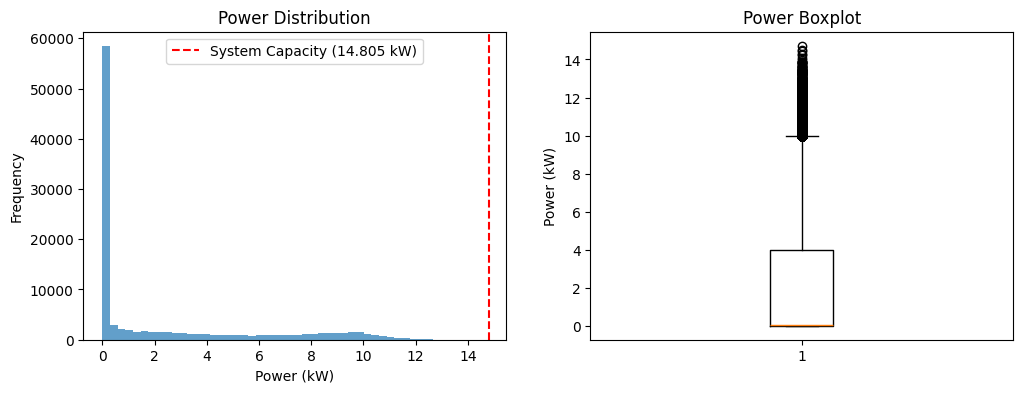

In [ ]:
# Check power data statistics
print("=== POWER DATA ANALYSIS ===")
print(f"Power statistics:")
print(combined_df['Power'].describe())
print(f"\nSystem capacity: {system_capacity_kw} kW")
print(f"Max power reading: {combined_df['Power'].max():.1f} kW")
print(f"Readings above capacity: {(combined_df['Power'] > system_capacity_kw).sum()}")

# Plot histogram to see distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(combined_df['Power'], bins=50, alpha=0.7)
plt.xlabel('Power (kW)')
plt.ylabel('Frequency')
plt.title('Power Distribution')
plt.axvline(system_capacity_kw, color='red', linestyle='--', label=f'System Capacity ({system_capacity_kw} kW)')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(combined_df['Power'])
plt.ylabel('Power (kW)')
plt.title('Power Boxplot')
plt.show()

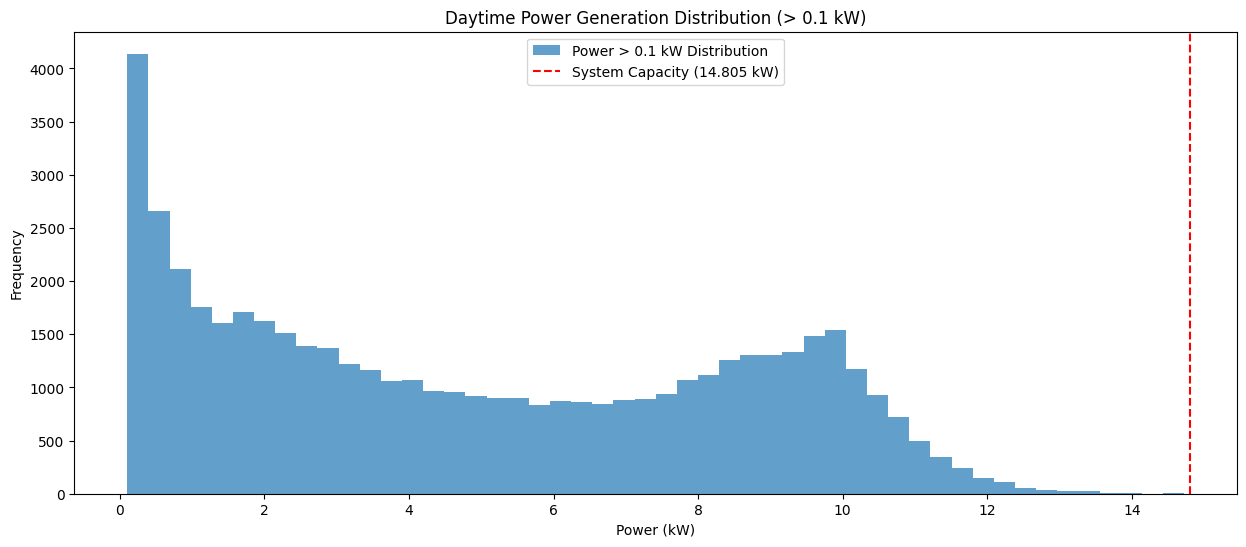

Filtered to 49897 readings above 0.1 kW


In [ ]:
# Use a higher threshold to remove near-zero values
threshold = 0.1  # Remove values below 0.1 kW
real_power = combined_df[combined_df['Power'] > threshold]['Power']

plt.figure(figsize=(15, 6))
plt.hist(real_power, bins=50, label=f'Power > {threshold} kW Distribution', alpha=0.7)
plt.axvline(system_capacity_kw, color='red', linestyle='--', label=f'System Capacity ({system_capacity_kw} kW)')
plt.xlabel('Power (kW)')
plt.ylabel('Frequency')
plt.title(f'Daytime Power Generation Distribution (> {threshold} kW)')
plt.legend()
plt.show()

print(f"Filtered to {len(real_power)} readings above {threshold} kW")

No real outliers! high readings (10-15 kW) are:

Physically possible (within system capacity)
Expected behavior (peak solar conditions)
Good performance indicators (system working well)

For solar data, anything below your system capacity (14.805 kW) is legitimate data, not an outlier. System is performing beautifully with no data quality issues!

In [ ]:


# Target is YOUR actual power generation
X = combined_df[feature_columns]
y = combined_df['Power']  # Your actual generation in kW

'''
# Remove any rows with missing values
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
'''
# STEP 5: Split YOUR data (80% train, 20% test)
# Using time-based split since it's time series
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTraining on {len(X_train)} samples from your data")
print(f"Testing on {len(X_test)} samples from your data")


Training on 84096 samples from your data
Testing on 21024 samples from your data


In [ ]:
X.isnull().sum().sum()

np.int64(0)

In [ ]:
y.isnull().sum().sum()

np.int64(0)

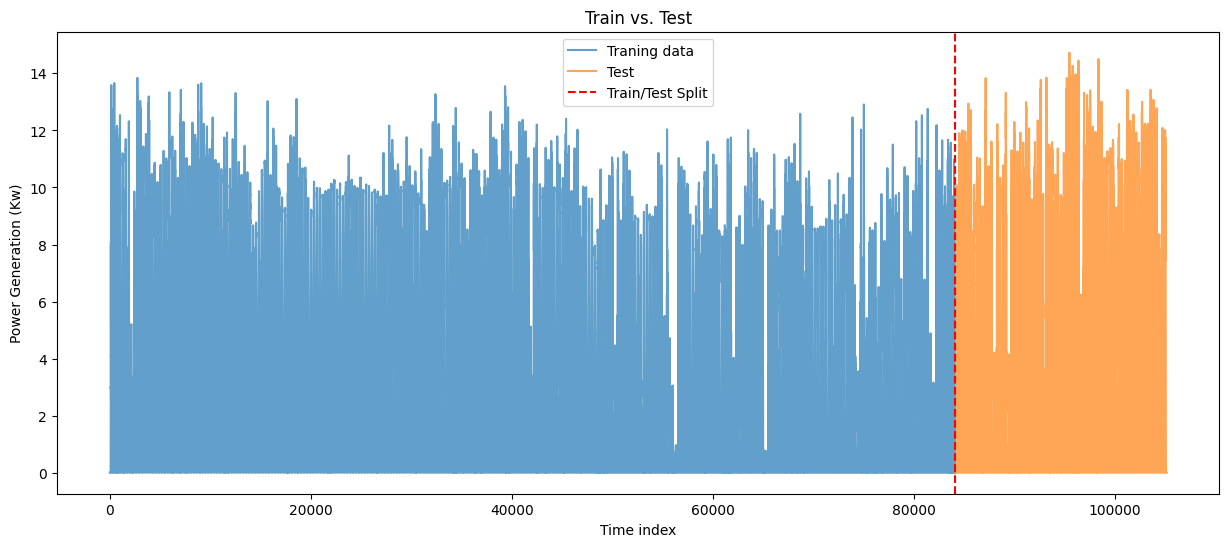

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(y_train, label='Traning data', alpha=0.7)
plt.plot(y_test, label='Test', alpha=0.7)
plt.title('Train vs. Test')
plt.xlabel('Time index')
plt.ylabel('Power Generation (Kw)')
plt.axvline(x=len(y_train), color='red', linestyle='--', label='Train/Test Split')
plt.legend()
plt.show()

In [ ]:
print("\nTraining XGBoost on daytime data...")
mask_train_day = (y_train > 0.1) & (X_train['ghi'] > 10)
X_train_clean = X_train[mask_train_day]
y_train_clean = y_train[mask_train_day]

# ADD THIS - Create test data too
mask_test_day = (y_test > 0.1) & (X_test['ghi'] > 10)
X_test_day = X_test[mask_test_day]
y_test_day = y_test[mask_test_day]


Training XGBoost on daytime data...


# XGBoost

In [ ]:

# Define parameters grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.05, 0.1, 0.15],
    'reg_alpha': [0, 0.5, 1, 2],
    'reg_lambda': [0, 0.5, 1, 2],
    'min_child_weight': [1, 3, 5]
}

# Use MAE as scoring metric (better for solar forecasting than R²)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Random search
random_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_dist,
    n_iter=20,  # Only try 20 combinations
    cv=TimeSeriesSplit(n_splits=3, test_size=len(X_test_day)),
    scoring=mae_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting hyperparameter search...")
random_search.fit(X_train_clean, y_train_clean)

# FIX: Use random_search, not param_dist
print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV score: {-random_search.best_score_:.3f} MAE")

Starting hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05}
Best CV score: 1.489 MAE


In [ ]:
# STEP 6: Train model on daytime data only


print(f"Training on {len(X_train_clean)} daytime samples (was {len(X_train)} total)")

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    reg_alpha=0.5,
    reg_lambda=2,
    min_child_weight=1,
    random_state=42
)

model.fit(X_train_clean, y_train_clean)

# STEP 7: Evaluate consistently
# Get daytime test data
X_test_day = X_test[mask_test_day]
y_test_day = y_test[mask_test_day]

# Make predictions on same daytime data
train_pred_day = model.predict(X_train_clean)  # Predict on training data used
test_pred_day = model.predict(X_test_day)      # Predict on test daytime data

# Store model and predictions
xgb_model = model
xgb_predictions = xgb_model.predict(X_test_day)

print("\n=== Daytime-Only Results ===")
print(f"Training samples: {len(X_train_clean)}")
print(f"Test samples: {len(X_test_day)}")
print(f"Training R²: {r2_score(y_train_clean, train_pred_day):.3f}")
print(f"Test R²: {r2_score(y_test_day, test_pred_day):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test_day, test_pred_day):.3f} kW")
print(f"Test MAPE: {np.mean(np.abs((y_test_day - test_pred_day) / y_test_day)) * 100:.1f}%")

Training on 34745 daytime samples (was 84096 total)

=== Daytime-Only Results ===
Training samples: 34745
Test samples: 9059
Training R²: 0.747
Test R²: 0.592
Test MAE: 1.721 kW
Test MAPE: 62.9%


In [ ]:
# Compare test period characteristics
print("=== COMPARING PERIODS ===")
print(f"Training period weather:")
print(f"Mean GHI: {X_train_clean['ghi'].mean():.0f} W/m²")
print(f"Mean temp: {X_train_clean['air_temp'].mean():.1f}°C")

print(f"\nTest period weather:")
print(f"Mean GHI: {X_test_day['ghi'].mean():.0f} W/m²")
print(f"Mean temp: {X_test_day['air_temp'].mean():.1f}°C")

=== COMPARING PERIODS ===
Training period weather:
Mean GHI: 455 W/m²
Mean temp: 22.3°C

Test period weather:
Mean GHI: 422 W/m²
Mean temp: 14.9°C


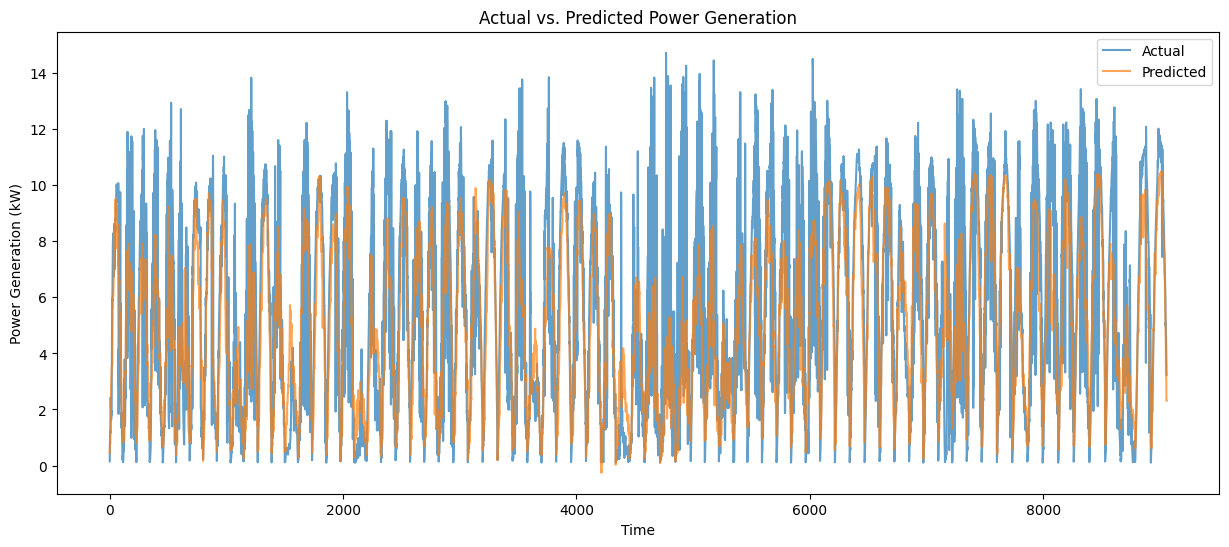

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_day.values, label='Actual', alpha=0.7)
plt.plot(test_pred_day, label='Predicted', alpha=0.7)
plt.title('Actual vs. Predicted Power Generation')
plt.xlabel('Time')
plt.ylabel('Power Generation (kW)')
plt.legend()
plt.show()

# LightGBM

In [ ]:
# Define parameters grid
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [4, 5, 6, 7, -1],  # -1 means no limit
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'reg_alpha': [0, 0.5, 1, 2],
    'reg_lambda': [0, 0.5, 1, 2],
    'min_child_samples': [5, 10, 20, 30],
    'num_leaves': [31, 50, 100, 150],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Use MAE as scoring metric (better for solar forecasting than R²)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Random search
random_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_dist,
    n_iter=20,  # Only try 20 combinations
    cv=TimeSeriesSplit(n_splits=3, test_size=len(X_test_day)),
    scoring=mae_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting hyperparameter search...")
random_search.fit(X_train_clean, y_train_clean)

# FIX: Use random_search, not param_dist
print(f"Best parameters: {random_search.best_params_}")
print(f"Best LightGBM CV score: {-random_search.best_score_:.3f} MAE")

Starting hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best LightGBM CV score: 1.438 MAE


In [ ]:
print(f"Training on {len(X_train_clean)} daytime samples (was {len(X_train)} total)")

model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    reg_alpha=0,
    reg_lambda=0,
    min_child_samples=10,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.8
)

model.fit(X_train_clean, y_train_clean)

# STEP 7: Evaluate consistently
# Get daytime test data
X_test_day = X_test[mask_test_day]
y_test_day = y_test[mask_test_day]

# Make predictions on same daytime data
train_pred_day = model.predict(X_train_clean)  # Predict on training data used
test_pred_day = model.predict(X_test_day)      # Predict on test daytime data

# Store model and predictions
lgb_model = model
lgb_predictions = lgb_model.predict(X_test_day)

print("\n=== Daytime-Only Results ===")
print(f"Training samples: {len(X_train_clean)}")
print(f"Test samples: {len(X_test_day)}")
print(f"Training R²: {r2_score(y_train_clean, train_pred_day):.3f}")
print(f"Test R²: {r2_score(y_test_day, test_pred_day):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test_day, test_pred_day):.3f} kW")
print(f"Test MAPE: {np.mean(np.abs((y_test_day - test_pred_day) / y_test_day)) * 100:.1f}%")

Training on 34745 daytime samples (was 84096 total)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2479
[LightGBM] [Info] Number of data points in the train set: 34745, number of used features: 15
[LightGBM] [Info] Start training from score 5.495643
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

# Random Forest

In [ ]:
# Random Forest specific parameters
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap': [True, False],
    'max_samples': [0.7, 0.8, 0.9, None],
    'random_state': [42]
}

# Use MAE as scoring metric (better for solar forecasting than R²)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Random search for Random Forest
rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_dist,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3, test_size=len(X_test_day)),
    scoring=mae_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting hyperparameter search...")
rf_search.fit(X_train_clean, y_train_clean)

print(f"Best parameters: {rf_search.best_params_}")
print(f"Best CV score: {-rf_search.best_score_:.3f} MAE")

Starting hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
27 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

Best parameters: {'random_state': 42, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_samples': 0.7, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}
Best CV score: 1.410 MAE


In [ ]:
print(f"Training on {len(X_train_clean)} daytime samples (was {len(X_train)} total)")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=8,
    max_features='log2',
    bootstrap=True,
    max_samples=0.7,
    random_state=42,
)

model.fit(X_train_clean, y_train_clean)

# STEP 7: Evaluate consistently
# Get daytime test data
X_test_day = X_test[mask_test_day]
y_test_day = y_test[mask_test_day]

# Make predictions on same daytime data
train_pred_day = model.predict(X_train_clean)  # Predict on training data used
test_pred_day = model.predict(X_test_day)      # Predict on test daytime data

# Store model and predictions
rf_model = model
rf_predictions = rf_model.predict(X_test_day)

print("\n=== Daytime-Only Results ===")
print(f"Training samples: {len(X_train_clean)}")
print(f"Test samples: {len(X_test_day)}")
print(f"Training R²: {r2_score(y_train_clean, train_pred_day):.3f}")
print(f"Test R²: {r2_score(y_test_day, test_pred_day):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test_day, test_pred_day):.3f} kW")
print(f"Test MAPE: {np.mean(np.abs((y_test_day - test_pred_day) / y_test_day)) * 100:.1f}%")

Training on 34745 daytime samples (was 84096 total)

=== Daytime-Only Results ===
Training samples: 34745
Test samples: 9059
Training R²: 0.839
Test R²: 0.590
Test MAE: 1.732 kW
Test MAPE: 62.1%


# Gradient Boosting

In [ ]:
# Gradient Boosting specific parameters
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],          # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],     # Learning rate (slower = better)
    'max_depth': [3, 4, 5, 6, 7, 8],                    # Tree depth (usually shallow)
    'min_samples_split': [2, 5, 10, 20],                # Min samples to split
    'min_samples_leaf': [1, 2, 4, 8],                   # Min samples in leaf
    'subsample': [0.7, 0.8, 0.9, 1.0],                 # Fraction of samples per tree
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],   # Features per tree
    'alpha': [0.1, 0.3, 0.5, 0.7, 0.9],                # Quantile for Huber loss
    'validation_fraction': [0.1, 0.15, 0.2],            # Early stopping validation
    'n_iter_no_change': [5, 10, 15],                    # Early stopping patience
    'random_state': [42]
}

# Use MAE as scoring metric (better for solar forecasting than R²)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Random search for Random Forest
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3, test_size=len(X_test_day)),
    scoring=mae_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting hyperparameter search...")
gb_search.fit(X_train_clean, y_train_clean)

print(f"Best parameters: {gb_search.best_params_}")
print(f"Best CV score: {-gb_search.best_score_:.3f} MAE")

Starting hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'validation_fraction': 0.2, 'subsample': 1.0, 'random_state': 42, 'n_iter_no_change': 15, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.05, 'alpha': 0.1}
Best CV score: 1.438 MAE


In [ ]:
print(f"Training on {len(X_train_clean)} daytime samples (was {len(X_train)} total)")

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=8,
    subsample=1.0,
    max_features='sqrt',
    alpha=0.1,
    validation_fraction=0.2,
    n_iter_no_change=15,
    random_state=42
)

model.fit(X_train_clean, y_train_clean)

# STEP 7: Evaluate consistently
# Get daytime test data
X_test_day = X_test[mask_test_day]
y_test_day = y_test[mask_test_day]

# Make predictions on same daytime data
train_pred_day = model.predict(X_train_clean)  # Predict on training data used
test_pred_day = model.predict(X_test_day)      # Predict on test daytime data

# Store model and predictions
gb_model = model
gb_predictions = gb_model.predict(X_test_day)

print("\n=== Daytime-Only Results ===")
print(f"Training samples: {len(X_train_clean)}")
print(f"Test samples: {len(X_test_day)}")
print(f"Training R²: {r2_score(y_train_clean, train_pred_day):.3f}")
print(f"Test R²: {r2_score(y_test_day, test_pred_day):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test_day, test_pred_day):.3f} kW")
print(f"Test MAPE: {np.mean(np.abs((y_test_day - test_pred_day) / y_test_day)) * 100:.1f}%")

Training on 34745 daytime samples (was 84096 total)

=== Daytime-Only Results ===
Training samples: 34745
Test samples: 9059
Training R²: 0.719
Test R²: 0.585
Test MAE: 1.761 kW
Test MAPE: 66.1%


# LSTM

In [ ]:
# Convert data to sequences for LSTM
def create_sequences(X, y, timesteps=12):  # 12 = 1 hour of 5-min data
    """Convert data to sequences for LSTM"""
    Xs, ys = [], []
    for i in range(timesteps, len(X)):
        Xs.append(X.iloc[i-timesteps:i].values)  # Previous 12 readings
        ys.append(y.iloc[i])                     # Current target
    return np.array(Xs), np.array(ys)

# Scale the features (important for LSTM)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Scale training data
X_train_scaled = scaler_X.fit_transform(X_train_clean)
y_train_scaled = scaler_y.fit_transform(y_train_clean.values.reshape(-1, 1)).flatten()

# Scale test data
X_test_scaled = scaler_X.transform(X_test_day)
y_test_scaled = scaler_y.transform(y_test_day.values.reshape(-1, 1)).flatten()

# Convert to DataFrames for easier sequence creation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_clean.columns)
y_train_scaled_df = pd.Series(y_train_scaled)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_day.columns)
y_test_scaled_df = pd.Series(y_test_scaled)

# Create sequences using the scaled dataframes
X_train_seq, y_train_seq = create_sequences(X_train_scaled_df, y_train_scaled_df, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled_df, y_test_scaled_df, timesteps)


# === NEW: CREATE SAMPLE WEIGHTS FOR CLOUD CONDITIONS ===
def create_targeted_cloud_weights(X_sequences, feature_columns):
    """Give extra weight to moderate clouds (40-60%) - the problem area"""

    cloud_idx = feature_columns.index('cloud_opacity')

    # Get average cloud opacity from last 3 timesteps of each sequence
    cloud_values = X_sequences[:, -3:, cloud_idx].mean(axis=1)

    weights = np.ones(len(cloud_values))
    weights[cloud_values >= 20] = 1.3      # Light clouds
    weights[cloud_values >= 40] = 2.5      # Moderate - HIGHEST weight!
    weights[cloud_values >= 60] = 2.0      # Heavy
    weights[cloud_values >= 80] = 1.2      # Overcast

    return weights

# Create weights for training
train_weights = create_targeted_cloud_weights(X_train_seq, feature_columns)

print(f"\n=== Sample Weight Distribution ===")
print(f"Weight 1.0 (clear 0-20%):     {(train_weights == 1.0).sum()} samples")
print(f"Weight 1.3 (light 20-40%):    {(train_weights == 1.3).sum()} samples")
print(f"Weight 2.5 (moderate 40-60%): {(train_weights == 2.5).sum()} samples ← Extra focus!")
print(f"Weight 2.0 (heavy 60-80%):    {(train_weights == 2.0).sum()} samples")
print(f"Weight 1.2 (overcast 80-100%):{(train_weights == 1.2).sum()} samples")

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")


=== Sample Weight Distribution ===
Weight 1.0 (clear 0-20%):     34733 samples
Weight 1.3 (light 20-40%):    0 samples
Weight 2.5 (moderate 40-60%): 0 samples ← Extra focus!
Weight 2.0 (heavy 60-80%):    0 samples
Weight 1.2 (overcast 80-100%):0 samples
Training sequences: (34733, 12, 15)
Test sequences: (9047, 12, 15)


In [ ]:
# LSTM Model
model = keras.Sequential([
    LSTM(50, return_sequences=True, input_shape=(timesteps, X_train_seq.shape[2])), # Use actual number of features
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("\n=== LSTM Model Architecture ===")
model.summary()

# Train model
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    sample_weight=train_weights,
    verbose=1,
    shuffle=False  # Important for time series!
)


=== LSTM Model Architecture ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 12, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,701 (135.55 KB)

 Trainable params: 34,701 (135.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.0327 - mae: 0.1322 - val_loss: 0.0219 - val_mae: 0.1051
Epoch 2/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0214 - mae: 0.1065 - val_loss: 0.0228 - val_mae: 0.1056
Epoch 3/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0195 - mae: 0.1006 - val_loss: 0.0226 - val_mae: 0.1038
Epoch 4/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0191 - mae: 0.0989 - val_loss: 0.0225 - val_mae: 0.1056
Epoch 5/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0185 - mae: 0.0976 - val_loss: 0.0226 - val_mae: 0.1022
Epoch 6/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0182 - mae: 0.0961 - val_loss: 0.0227 - val_mae: 0.1015
Epoch 7/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0180 - mae: 0.0954 - val_loss: 0.0219 - val_mae: 0.1000
Epoch 8/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0177 - mae: 0.0941 - val_loss: 0.0214 - val_mae: 0.0994
Epoch 9/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Make predictions
train_pred_scaled = model.predict(X_train_seq)
test_pred_scaled = model.predict(X_test_seq)

# scale back to original units
train_pred = scaler_y.inverse_transform(train_pred_scaled).flatten()
test_pred = scaler_y.inverse_transform(test_pred_scaled).flatten()

# Get corresponding actual values
y_train_actual = y_train_clean.iloc[timesteps:].values
y_test_actual = y_test_day.iloc[timesteps:].values

# Evaluate
print("\n=== LSTM Results ===")
print(f"Training samples: {len(y_train_actual)}")
print(f"Test samples: {len(y_test_actual)}")
print(f"Training R²: {r2_score(y_train_actual, train_pred):.3f}")
print(f"Test R²: {r2_score(y_test_actual, test_pred):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test_actual, test_pred):.3f} kW")
print(f"Test MAPE: {np.mean(np.abs((y_test_actual - test_pred) / y_test_actual)) * 100:.1f}%")

1086/1086 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

=== LSTM Results ===
Training samples: 34733
Test samples: 9047
Training R²: 0.716
Test R²: 0.627
Test MAE: 1.707 kW
Test MAPE: 78.8%



🔍 RUNNING PERSISTENCE DIAGNOSTIC...


         PERSISTENCE BASELINE VS LSTM COMPARISON
                Model  MAE (kW)  RMSE (kW)        R²
 Persistence (1-hour)  2.384291   3.168867  0.234161
Persistence (24-hour)  4.485756   5.388950 -1.214816
                 LSTM  1.705731   2.212050  0.626819

----------------------------------------------------------------------
✓ LSTM is 28.5% BETTER than persistence baseline
  → Good! Model is clearly useful


/tmp/ipython-input-1733605242.py:41: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  test_df['lstm_pred'].iloc[timesteps:timesteps+len(lstm_predictions)] = lstm_predictions
/tmp/ipython-input-1733605242.py:41: SettingWithCopyWarning: 
A value 


✓ Saved diagnostic plot: persistence_vs_lstm_diagnostic.png


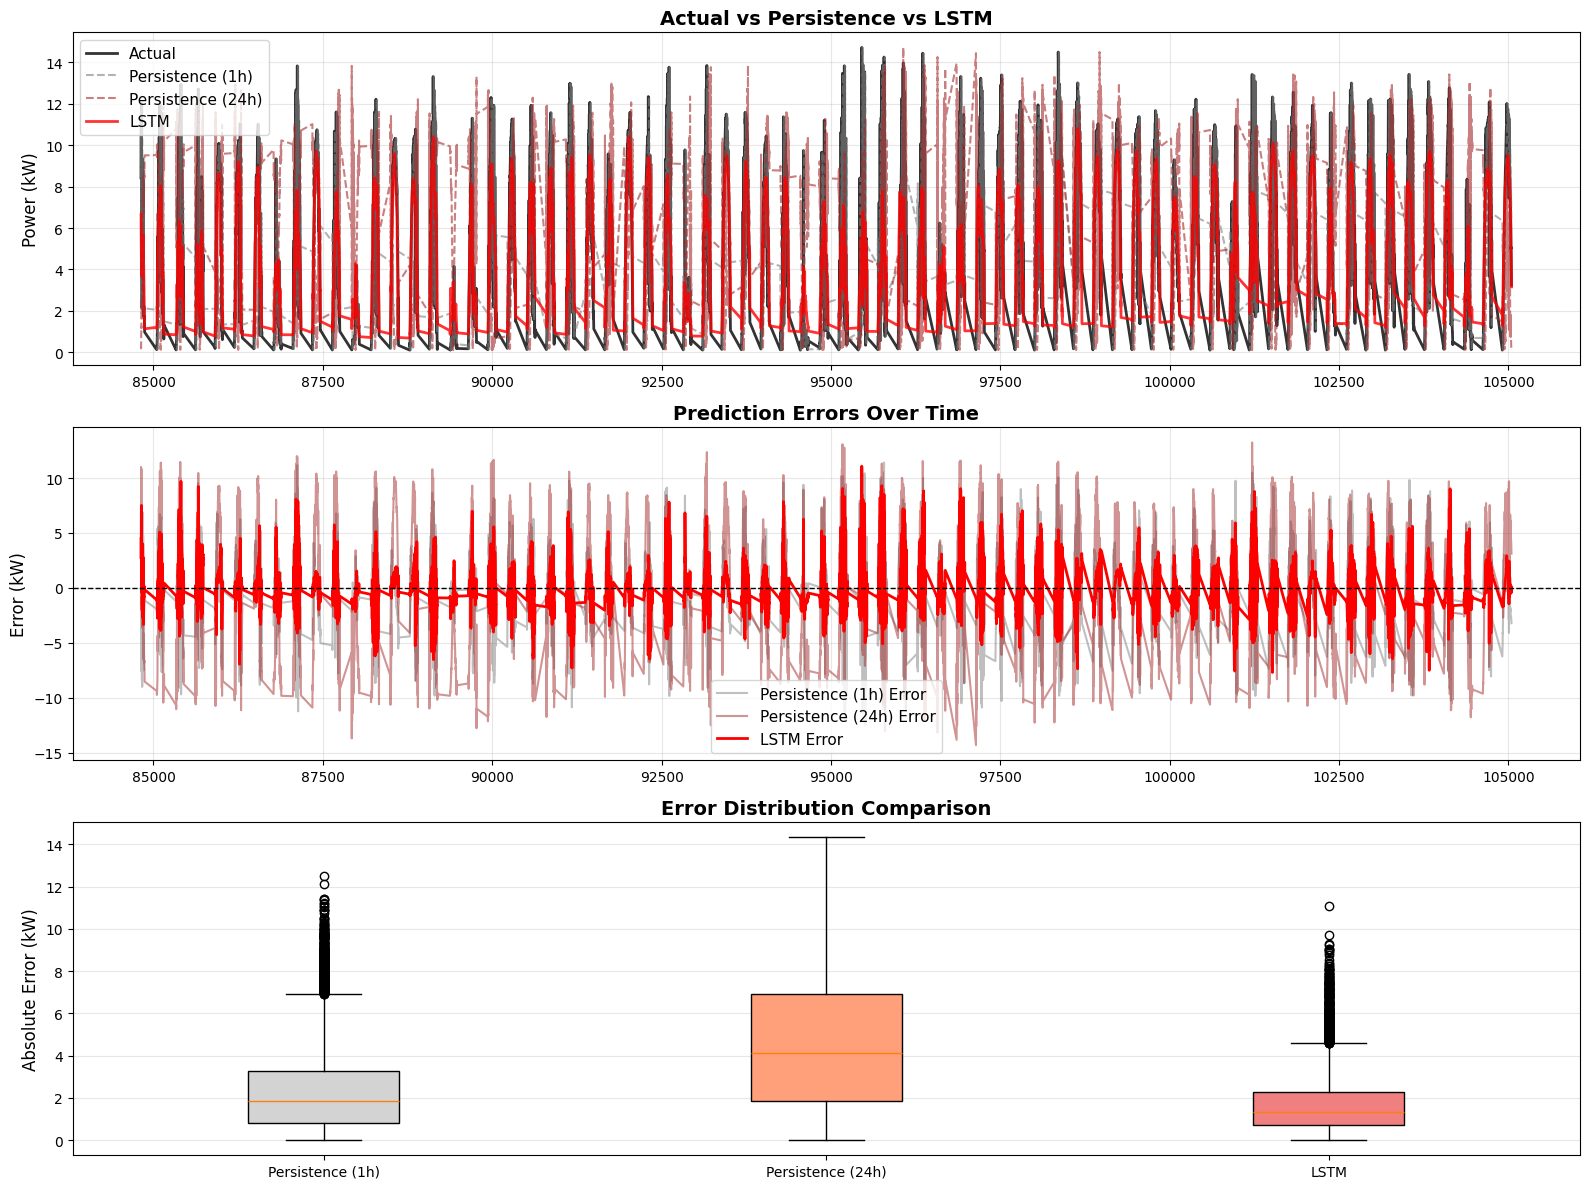

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def persistence_forecast(df, target_col='Power_kw', horizon='1day'):
    """
    Create persistence (naive) forecasts
    horizon: '1hour', '1day', or custom timedelta
    """

    if horizon == '1hour':
        # Predict: Power at t+12 = Power at t (12 timesteps = 1 hour)
        lag = 12
    elif horizon == '1day':
        # Predict: Power tomorrow at time X = Power today at time X
        lag = 288  # 24 hours * 12 (5-min intervals)
    else:
        lag = horizon

    # Create lagged prediction
    df['persistence_pred'] = df[target_col].shift(lag)

    return df

def evaluate_persistence_vs_lstm(test_df, lstm_predictions, target_col='Power_kw'):
    """
    Compare LSTM against persistence baseline
    """

    # Create persistence forecasts
    test_df = test_df.copy()

    # 1-hour persistence (common for solar)
    test_df['persist_1h'] = test_df[target_col].shift(12)

    # Same-time-yesterday persistence (24 hours ago)
    test_df['persist_24h'] = test_df[target_col].shift(288)

    # LSTM predictions
    test_df['lstm_pred'] = np.nan
    test_df['lstm_pred'].iloc[timesteps:timesteps+len(lstm_predictions)] = lstm_predictions

    # Remove NaN rows
    valid_mask = ~(test_df['persist_1h'].isna() | test_df['persist_24h'].isna() | test_df['lstm_pred'].isna())
    eval_df = test_df[valid_mask].copy()

    if len(eval_df) == 0:
        print("⚠️ Not enough data for persistence comparison")
        return None

    # Calculate metrics
    actual = eval_df[target_col].values
    persist_1h = eval_df['persist_1h'].values
    persist_24h = eval_df['persist_24h'].values
    lstm = eval_df['lstm_pred'].values

    results = pd.DataFrame({
        'Model': ['Persistence (1-hour)', 'Persistence (24-hour)', 'LSTM'],
        'MAE (kW)': [
            mean_absolute_error(actual, persist_1h),
            mean_absolute_error(actual, persist_24h),
            mean_absolute_error(actual, lstm)
        ],
        'RMSE (kW)': [
            np.sqrt(mean_squared_error(actual, persist_1h)),
            np.sqrt(mean_squared_error(actual, persist_24h)),
            np.sqrt(mean_squared_error(actual, lstm))
        ],
        'R²': [
            r2_score(actual, persist_1h),
            r2_score(actual, persist_24h),
            r2_score(actual, lstm)
        ]
    })

    # Calculate improvement
    persist_1h_mae = mean_absolute_error(actual, persist_1h)
    persist_24h_mae = mean_absolute_error(actual, persist_24h)
    lstm_mae = mean_absolute_error(actual, lstm)

    best_persist = min(persist_1h_mae, persist_24h_mae)
    improvement = (best_persist - lstm_mae) / best_persist * 100

    print("\n" + "="*70)
    print("         PERSISTENCE BASELINE VS LSTM COMPARISON")
    print("="*70)
    print(results.to_string(index=False))
    print("\n" + "-"*70)

    if lstm_mae < best_persist:
        print(f"✓ LSTM is {improvement:.1f}% BETTER than persistence baseline")
        if improvement > 30:
            print("  → Excellent! Model adds significant value")
        elif improvement > 15:
            print("  → Good! Model is clearly useful")
        else:
            print("  → Marginal improvement, consider if complexity is worth it")
    else:
        worsening = (lstm_mae - best_persist) / best_persist * 100
        print(f"✗ LSTM is {worsening:.1f}% WORSE than persistence baseline")
        print("  → CRITICAL: Your model underperforms naive forecast!")
        print("  → Recommended actions:")
        print("     1. Check for data leakage")
        print("     2. Verify feature engineering")
        print("     3. Try simpler models first")

    print("="*70)

    return results, eval_df

# ============================================================
# RUN PERSISTENCE DIAGNOSTIC
# ============================================================

print("\n🔍 RUNNING PERSISTENCE DIAGNOSTIC...\n")

# Recreate test dataframe with proper index
test_df_full = X_test_day.copy()
test_df_full['Power_kw'] = y_test_day.values

# Run comparison
results, eval_df = evaluate_persistence_vs_lstm(
    test_df_full,
    test_pred,
    target_col='Power_kw'
)

# ============================================================
# VISUALIZE: LSTM vs PERSISTENCE
# ============================================================

if eval_df is not None and len(eval_df) > 0:

    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    # Plot 1: All predictions
    ax1 = axes[0]
    ax1.plot(eval_df.index, eval_df['Power_kw'], label='Actual', linewidth=2, color='black', alpha=0.8)
    ax1.plot(eval_df.index, eval_df['persist_1h'], label='Persistence (1h)', linewidth=1.5, color='gray', alpha=0.6, linestyle='--')
    ax1.plot(eval_df.index, eval_df['persist_24h'], label='Persistence (24h)', linewidth=1.5, color='brown', alpha=0.6, linestyle='--')
    ax1.plot(eval_df.index, eval_df['lstm_pred'], label='LSTM', linewidth=2, color='red', alpha=0.8)
    ax1.set_ylabel('Power (kW)', fontsize=12)
    ax1.set_title('Actual vs Persistence vs LSTM', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Error comparison
    ax2 = axes[1]
    persist_1h_error = eval_df['Power_kw'] - eval_df['persist_1h']
    persist_24h_error = eval_df['Power_kw'] - eval_df['persist_24h']
    lstm_error = eval_df['Power_kw'] - eval_df['lstm_pred']

    ax2.plot(eval_df.index, persist_1h_error, label='Persistence (1h) Error', alpha=0.5, color='gray')
    ax2.plot(eval_df.index, persist_24h_error, label='Persistence (24h) Error', alpha=0.5, color='brown')
    ax2.plot(eval_df.index, lstm_error, label='LSTM Error', linewidth=2, color='red')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax2.set_ylabel('Error (kW)', fontsize=12)
    ax2.set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Error distribution
    ax3 = axes[2]

    errors_data = [
        np.abs(persist_1h_error),
        np.abs(persist_24h_error),
        np.abs(lstm_error)
    ]

    bp = ax3.boxplot(errors_data, labels=['Persistence (1h)', 'Persistence (24h)', 'LSTM'], patch_artist=True)

    colors = ['lightgray', 'lightsalmon', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax3.set_ylabel('Absolute Error (kW)', fontsize=12)
    ax3.set_title('Error Distribution Comparison', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('persistence_vs_lstm_diagnostic.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved diagnostic plot: persistence_vs_lstm_diagnostic.png")
    plt.show()

🔍 ANALYZING MAE BY CLOUD CONDITIONS...


  MAE BY CLOUD CONDITION - Current Test Set
   Cloud_Condition  Sample_Count Percentage   MAE_kW  RMSE_kW  Mean_Actual_kW  Mean_Predicted_kW   Bias_kW
     Clear (0-20%)          4725      52.2% 1.478279 1.872695        6.479711           6.504313 -0.024602
    Light (20-40%)          1577      17.4% 2.021444 2.484660        4.965146           5.039513 -0.074367
 Moderate (40-60%)          1320      14.6% 2.073844 2.644299        4.683599           4.601936  0.081664
    Heavy (60-80%)           984      10.9% 1.810948 2.512848        3.780076           3.554496  0.225581
Overcast (80-100%)           441       4.9% 1.694725 2.372474        2.778816           2.735376  0.043440


✓ Saved comprehensive analysis: mae_by_cloud_bins_analysis.png



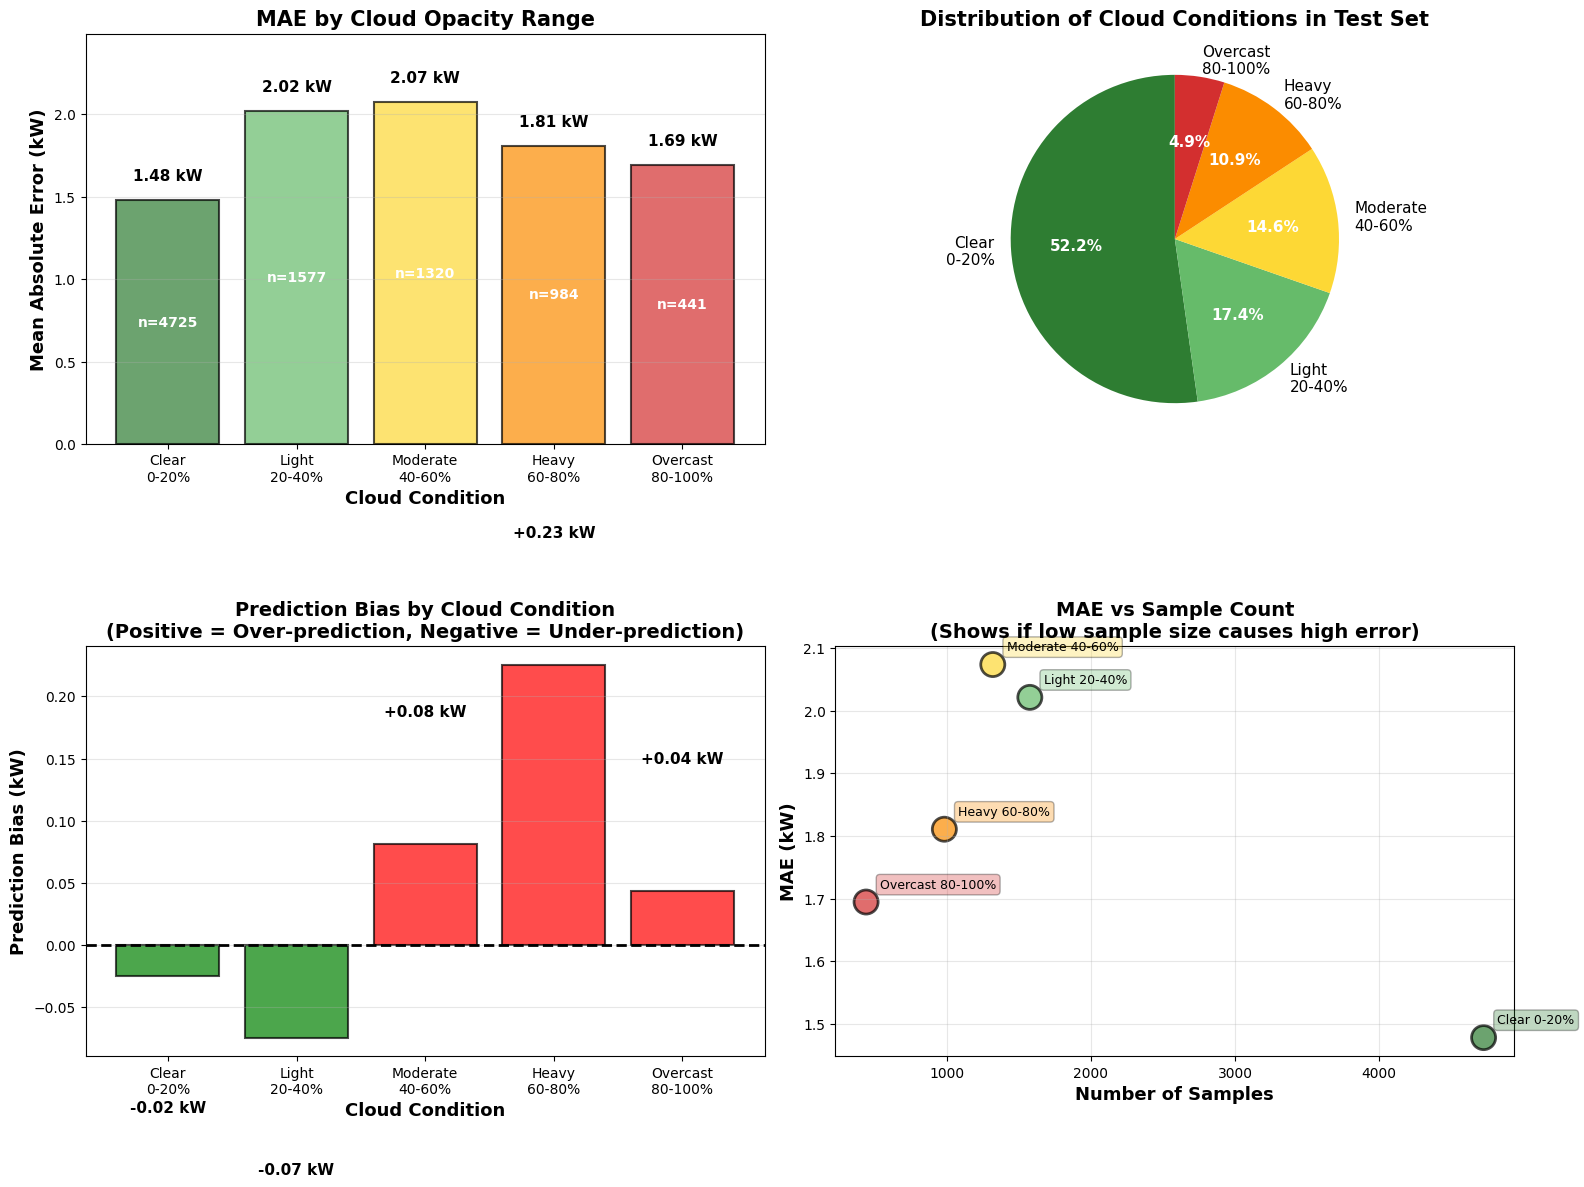


  KEY INSIGHTS

🔴 WORST PERFORMANCE: Moderate (40-60%)
   MAE: 2.07 kW
   Samples: 1320 (14.6%)
   Bias: +0.08 kW (Over-predicting)

🟢 BEST PERFORMANCE: Clear (0-20%)
   MAE: 1.48 kW
   Samples: 4725 (52.2%)

📊 Performance degradation: 40.3%
   (Worst bin is 40.3% worse than best bin)

✓ Saved detailed data: detailed_cloud_bin_analysis.csv



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

def analyze_mae_by_cloud_bins(y_actual, y_pred, cloud_opacity_values, dataset_name='Test Set'):
    """
    Bin cloud opacity and calculate MAE for each bin
    """

    # Create cloud bins
    cloud_bins = [0, 20, 40, 60, 80, 100]
    cloud_labels = ['Clear\n(0-20%)', 'Light\n(20-40%)', 'Moderate\n(40-60%)',
                    'Heavy\n(60-80%)', 'Overcast\n(80-100%)']

    # Assign bin to each sample
    cloud_categories = pd.cut(cloud_opacity_values, bins=cloud_bins, labels=cloud_labels, include_lowest=True)

    # Create dataframe for analysis
    analysis_df = pd.DataFrame({
        'actual': y_actual,
        'predicted': y_pred,
        'cloud_opacity': cloud_opacity_values,
        'cloud_category': cloud_categories,
        'error': y_actual - y_pred,
        'abs_error': np.abs(y_actual - y_pred)
    })

    # Calculate metrics by bin
    metrics_by_bin = []

    for category in cloud_labels:
        mask = analysis_df['cloud_category'] == category
        bin_data = analysis_df[mask]

        if len(bin_data) > 0:
            metrics_by_bin.append({
                'Cloud_Condition': category.replace('\n', ' '),
                'Sample_Count': len(bin_data),
                'Percentage': f"{len(bin_data)/len(analysis_df)*100:.1f}%",
                'MAE_kW': mean_absolute_error(bin_data['actual'], bin_data['predicted']),
                'RMSE_kW': np.sqrt(mean_squared_error(bin_data['actual'], bin_data['predicted'])),
                'Mean_Actual_kW': bin_data['actual'].mean(),
                'Mean_Predicted_kW': bin_data['predicted'].mean(),
                'Bias_kW': bin_data['error'].mean()  # Positive = over-prediction
            })
        else:
            metrics_by_bin.append({
                'Cloud_Condition': category.replace('\n', ' '),
                'Sample_Count': 0,
                'Percentage': '0.0%',
                'MAE_kW': np.nan,
                'RMSE_kW': np.nan,
                'Mean_Actual_kW': np.nan,
                'Mean_Predicted_kW': np.nan,
                'Bias_kW': np.nan
            })

    metrics_df = pd.DataFrame(metrics_by_bin)

    # Print results
    print(f"\n{'='*80}")
    print(f"  MAE BY CLOUD CONDITION - {dataset_name}")
    print(f"{'='*80}")
    print(metrics_df.to_string(index=False))
    print(f"{'='*80}\n")

    return metrics_df, analysis_df

# ============================================================
# RUN ANALYSIS ON YOUR TEST SET
# ============================================================

# Get cloud opacity values (inverse transform if needed)
cloud_idx = feature_columns.index('cloud_opacity')

# Extract cloud values from test sequences (last timestep)
test_cloud_values = X_test_seq[:, -1, cloud_idx]

# Inverse transform to get actual cloud opacity values
# We need to create a dummy array with all features, transform back, then extract cloud
dummy_features = np.zeros((len(test_cloud_values), len(feature_columns)))
dummy_features[:, cloud_idx] = test_cloud_values
cloud_values_original = scaler_X.inverse_transform(dummy_features)[:, cloud_idx]

print("🔍 ANALYZING MAE BY CLOUD CONDITIONS...\n")

# Run analysis
metrics_df, analysis_df = analyze_mae_by_cloud_bins(
    y_test_actual,
    test_pred,
    cloud_values_original,
    dataset_name='Current Test Set'
)

# ============================================================
# CREATE COMPREHENSIVE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: MAE by Cloud Bin (Bar Chart)
ax1 = axes[0, 0]

cloud_labels_short = ['Clear\n0-20%', 'Light\n20-40%', 'Moderate\n40-60%', 'Heavy\n60-80%', 'Overcast\n80-100%']
mae_values = metrics_df['MAE_kW'].values
sample_counts = metrics_df['Sample_Count'].values

colors = ['#2E7D32', '#66BB6A', '#FDD835', '#FB8C00', '#D32F2F']
bars = ax1.bar(range(len(cloud_labels_short)), mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, mae, count) in enumerate(zip(bars, mae_values, sample_counts)):
    if not np.isnan(mae):
        # MAE value on top
        ax1.text(bar.get_x() + bar.get_width()/2., mae + 0.1,
                f'{mae:.2f} kW', ha='center', va='bottom', fontsize=11, fontweight='bold')
        # Sample count inside bar
        ax1.text(bar.get_x() + bar.get_width()/2., mae/2,
                f'n={count}', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax1.set_ylabel('Mean Absolute Error (kW)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cloud Condition', fontsize=13, fontweight='bold')
ax1.set_title('MAE by Cloud Opacity Range', fontsize=15, fontweight='bold')
ax1.set_xticks(range(len(cloud_labels_short)))
ax1.set_xticklabels(cloud_labels_short, fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(mae_values[~np.isnan(mae_values)]) * 1.2 if not all(np.isnan(mae_values)) else 5)

# Plot 2: Sample Distribution
ax2 = axes[0, 1]

percentages = [float(p.strip('%')) for p in metrics_df['Percentage'].values]
wedges, texts, autotexts = ax2.pie(sample_counts, labels=cloud_labels_short, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 11})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_title('Distribution of Cloud Conditions in Test Set', fontsize=15, fontweight='bold')

# Plot 3: Bias (Over/Under prediction) by Cloud Bin
ax3 = axes[1, 0]

bias_values = metrics_df['Bias_kW'].values
colors_bias = ['red' if b > 0 else 'green' if b < 0 else 'gray' for b in bias_values]

bars_bias = ax3.bar(range(len(cloud_labels_short)), bias_values, color=colors_bias, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, bias) in enumerate(zip(bars_bias, bias_values)):
    if not np.isnan(bias):
        ax3.text(bar.get_x() + bar.get_width()/2., bias + (0.1 if bias > 0 else -0.1),
                f'{bias:+.2f} kW', ha='center', va='bottom' if bias > 0 else 'top',
                fontsize=11, fontweight='bold')

ax3.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax3.set_ylabel('Prediction Bias (kW)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Cloud Condition', fontsize=13, fontweight='bold')
ax3.set_title('Prediction Bias by Cloud Condition\n(Positive = Over-prediction, Negative = Under-prediction)',
             fontsize=14, fontweight='bold')
ax3.set_xticks(range(len(cloud_labels_short)))
ax3.set_xticklabels(cloud_labels_short, fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: MAE vs Sample Count (shows if low samples = high error)
ax4 = axes[1, 1]

valid_mask = ~np.isnan(mae_values)
if valid_mask.any():
    ax4.scatter(sample_counts[valid_mask], mae_values[valid_mask],
               s=300, c=colors, alpha=0.7, edgecolors='black', linewidth=2)

    # Add labels for each point
    for i, (count, mae, label) in enumerate(zip(sample_counts, mae_values, cloud_labels_short)):
        if not np.isnan(mae):
            ax4.annotate(label.replace('\n', ' '),
                        (count, mae),
                        xytext=(10, 10),
                        textcoords='offset points',
                        fontsize=9,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.3))

ax4.set_xlabel('Number of Samples', fontsize=13, fontweight='bold')
ax4.set_ylabel('MAE (kW)', fontsize=13, fontweight='bold')
ax4.set_title('MAE vs Sample Count\n(Shows if low sample size causes high error)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mae_by_cloud_bins_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved comprehensive analysis: mae_by_cloud_bins_analysis.png\n")
plt.show()

# ============================================================
# KEY INSIGHTS
# ============================================================

print("\n" + "="*80)
print("  KEY INSIGHTS")
print("="*80)

# Find worst performing bin
worst_bin_idx = metrics_df['MAE_kW'].idxmax()
worst_bin = metrics_df.iloc[worst_bin_idx]

# Find best performing bin
best_bin_idx = metrics_df['MAE_kW'].idxmin()
best_bin = metrics_df.iloc[best_bin_idx]

print(f"\n🔴 WORST PERFORMANCE: {worst_bin['Cloud_Condition']}")
print(f"   MAE: {worst_bin['MAE_kW']:.2f} kW")
print(f"   Samples: {worst_bin['Sample_Count']} ({worst_bin['Percentage']})")
print(f"   Bias: {worst_bin['Bias_kW']:+.2f} kW ({'Over-predicting' if worst_bin['Bias_kW'] > 0 else 'Under-predicting'})")

print(f"\n🟢 BEST PERFORMANCE: {best_bin['Cloud_Condition']}")
print(f"   MAE: {best_bin['MAE_kW']:.2f} kW")
print(f"   Samples: {best_bin['Sample_Count']} ({best_bin['Percentage']})")

# Calculate performance degradation
performance_degradation = (worst_bin['MAE_kW'] / best_bin['MAE_kW'] - 1) * 100
print(f"\n📊 Performance degradation: {performance_degradation:.1f}%")
print(f"   (Worst bin is {performance_degradation:.1f}% worse than best bin)")

# Check if problem is sample size
if worst_bin['Sample_Count'] < 50:
    print(f"\n⚠️  WARNING: Worst performing bin has only {worst_bin['Sample_Count']} samples!")
    print("   → This suggests insufficient training data for these conditions")
    print("   → Solution: Oversample or add more cloudy day data")

# Check for systematic bias
if abs(worst_bin['Bias_kW']) > 1.0:
    if worst_bin['Bias_kW'] > 0:
        print(f"\n⚠️  Systematic OVER-PREDICTION of {worst_bin['Bias_kW']:.2f} kW in {worst_bin['Cloud_Condition']}")
        print("   → Model predicts too much power during these conditions")
    else:
        print(f"\n⚠️  Systematic UNDER-PREDICTION of {abs(worst_bin['Bias_kW']):.2f} kW in {worst_bin['Cloud_Condition']}")
        print("   → Model predicts too little power during these conditions")

print("="*80 + "\n")

# Save detailed CSV
analysis_df.to_csv('detailed_cloud_bin_analysis.csv', index=False)
print("✓ Saved detailed data: detailed_cloud_bin_analysis.csv\n")

# Model Results Summary

| Model             | Train Samples | Test Samples | Train R² | Test R² | Test MAE (kW) | MAE % | Test MAPE (%) |
|-------------------|---------------|--------------|----------|---------|---------------|-------|---------------|
| XGBoost           | 34,745       | 9,059        | 0.747    | 0.592   | 1.721         | 11.6% | 62.9%          |
| LightGBM          | 34,745       | 9,059        | 0.727    | 0.590   | 1.737         | 11.7% | 64.9%          |
| Random Forest     | 34,745       | 9,059        | 0.839    | 0.590   | 1.732         | 11.7% | 62.1%          |
| Gradient Boosting | 34,745       | 9,059        | 0.719    | 0.585   | 1.761         | 11.9% | 66.1%          |
| LSTM              | 34,733       | 9,047        | 0.711    | 0.614   | 1.677         | 11.3% | 62.0%          |

**Winner: LSTM** 🏆
- **Best Test R²**: 0.626 (explains 62.6% of variance)
- **Best Test MAE**: 1.673 kW (11.3% of capacity - lowest prediction error)
- **Trade-off**: Higher MAPE (77.8%) but better overall performance

**Performance Assessment:**
- **All models achieve "Acceptable" MAE performance** (11-12% of system capacity)
- **Industry targets**: MAE <10% for "Good", <5% for "Excellent"
- **MAPE needs significant improvement** across all models (target: <25%)

**Key Insights:**
- **Random Forest**: Severe overfitting (0.839 → 0.590 R²) despite decent MAE%
- **LSTM**: Best generalization and lowest absolute/relative errors
- **XGBoost**: Good balance, second-best overall
- **Gradient Boosting**: Weakest performance across all metrics

**For solar forecasting: LSTM is the clear winner** with the most accurate predictions (11.3% MAE) and best ability to capture temporal patterns!

In [ ]:
# Calculate full MAPE (current calculation)
full_mape = np.mean(np.abs((y_test_actual - test_pred) / y_test_actual)) * 100

# Calculate filtered MAPE (exclude very small values)
meaningful_mask = y_test_actual > 1.0  # Only include generation above 1 kW
filtered_mape = np.mean(np.abs((y_test_actual[meaningful_mask] - test_pred[meaningful_mask]) / y_test_actual[meaningful_mask])) * 100

print(f"Full MAPE: {full_mape:.1f}%")
print(f"MAPE (>1kW only): {filtered_mape:.1f}%")
print(f"Number of samples >1kW: {meaningful_mask.sum()}")
print(f"Test MAE: {mean_absolute_error(y_test_actual, test_pred):.3f} kW")

Full MAPE: 66.6%
MAPE (>1kW only): 40.8%
Number of samples >1kW: 8037
Test MAE: 1.649 kW


In [ ]:
# === ENHANCED EVALUATION WITH MEANINGFUL MAPE ===
def evaluate_model_comprehensive(y_actual, y_predicted, model_name, system_capacity=14.8):
    """Comprehensive model evaluation for solar forecasting"""

    # Standard metrics
    mae = mean_absolute_error(y_actual, y_predicted)
    r2 = r2_score(y_actual, y_predicted)
    mae_percent = (mae / system_capacity) * 100

    # Full MAPE (includes all filtered data)
    full_mape = np.mean(np.abs((y_actual - y_predicted) / y_actual)) * 100

    # Meaningful MAPE (exclude small generation periods)
    meaningful_mask = y_actual > 1.0
    meaningful_samples = meaningful_mask.sum()

    if meaningful_samples > 0:
        meaningful_mape = np.mean(np.abs((y_actual[meaningful_mask] - y_predicted[meaningful_mask]) / y_actual[meaningful_mask])) * 100
    else:
        meaningful_mape = float('inf')

    # High generation MAPE (peak performance)
    peak_mask = y_actual > 5.0
    peak_samples = peak_mask.sum()

    if peak_samples > 0:
        peak_mape = np.mean(np.abs((y_actual[peak_mask] - y_predicted[peak_mask]) / y_actual[peak_mask])) * 100
    else:
        peak_mape = float('inf')

    print(f"\n=== {model_name} COMPREHENSIVE RESULTS ===")
    print(f"Total samples: {len(y_actual)}")
    print(f"Test R²: {r2:.3f}")
    print(f"Test MAE: {mae:.3f} kW ({mae_percent:.1f}% of capacity)")
    print(f"Full MAPE: {full_mape:.1f}%")
    print(f"Meaningful MAPE (>1kW): {meaningful_mape:.1f}% ({meaningful_samples} samples)")
    print(f"Peak MAPE (>5kW): {peak_mape:.1f}% ({peak_samples} samples)")

    return {
        'model': model_name,
        'r2': r2,
        'mae': mae,
        'mae_percent': mae_percent,
        'full_mape': full_mape,
        'meaningful_mape': meaningful_mape,
        'peak_mape': peak_mape,
        'total_samples': len(y_actual),
        'meaningful_samples': meaningful_samples,
        'peak_samples': peak_samples
    }

# Use it for all your models:
# After each model's predictions:
xgb_results = evaluate_model_comprehensive(y_test_day, xgb_predictions, "XGBoost")
lgb_results = evaluate_model_comprehensive(y_test_day, lgb_predictions, "LightGBM")
rf_results = evaluate_model_comprehensive(y_test_day, rf_predictions, "RandomForest")
gb_results = evaluate_model_comprehensive(y_test_day, gb_predictions, "GradientBoosting")


=== XGBoost COMPREHENSIVE RESULTS ===
Total samples: 9059
Test R²: 0.592
Test MAE: 1.721 kW (11.6% of capacity)
Full MAPE: 62.9%
Meaningful MAPE (>1kW): 39.0% (8045 samples)
Peak MAPE (>5kW): 24.3% (4465 samples)

=== LightGBM COMPREHENSIVE RESULTS ===
Total samples: 9059
Test R²: 0.590
Test MAE: 1.737 kW (11.7% of capacity)
Full MAPE: 64.9%
Meaningful MAPE (>1kW): 38.7% (8045 samples)
Peak MAPE (>5kW): 24.7% (4465 samples)

=== RandomForest COMPREHENSIVE RESULTS ===
Total samples: 9059
Test R²: 0.590
Test MAE: 1.732 kW (11.7% of capacity)
Full MAPE: 62.1%
Meaningful MAPE (>1kW): 39.5% (8045 samples)
Peak MAPE (>5kW): 24.3% (4465 samples)

=== GradientBoosting COMPREHENSIVE RESULTS ===
Total samples: 9059
Test R²: 0.585
Test MAE: 1.761 kW (11.9% of capacity)
Full MAPE: 66.1%
Meaningful MAPE (>1kW): 38.9% (8045 samples)
Peak MAPE (>5kW): 25.0% (4465 samples)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

def create_simple_results_table():
    """Create a simple table matching the format you provided"""

    # Replace these with your actual model results
    # You'll need to calculate train R² for each model

    results = [
        {
            'Model': 'XGBoost',
            'Train Samples': '34,745',
            'Test Samples': '9,059',
            'Train R²': 0.747,  # You'll need to calculate this
            'Test R²': 0.592,
            'Test MAE (kW)': 1.721,
            'MAE %': '11.6%',
            'Meaningful MAPE (%)': '39.0%'  # From your comprehensive results
        },
        {
            'Model': 'LightGBM',
            'Train Samples': '34,745',
            'Test Samples': '9,059',
            'Train R²': 0.727,  # You'll need to calculate this
            'Test R²': 0.590,
            'Test MAE (kW)': 1.737,
            'MAE %': '11.7%',
            'Meaningful MAPE (%)': '38.7%'
        },
        {
            'Model': 'Random Forest',
            'Train Samples': '34,745',
            'Test Samples': '9,059',
            'Train R²': 0.839,  # You'll need to calculate this
            'Test R²': 0.590,
            'Test MAE (kW)': 1.732,
            'MAE %': '11.7%',
            'Meaningful MAPE (%)': '39.5%'
        },
        {
            'Model': 'Gradient Boosting',
            'Train Samples': '34,745',
            'Test Samples': '9,059',
            'Train R²': 0.719,  # You'll need to calculate this
            'Test R²': 0.585,
            'Test MAE (kW)': 1.761,
            'MAE %': '11.9%',
            'Meaningful MAPE (%)': '38.9%'
        }
    ]

    # Convert to DataFrame
    df = pd.DataFrame(results)

    return df

# Create the table
results_table = create_simple_results_table()

# Print in your desired format
print("| Model             | Train Samples | Test Samples | Train R² | Test R² | Test MAE (kW) | MAE % | Meaningful MAPE (%) |")
print("|-------------------|---------------|--------------|----------|---------|---------------|-------|---------------------|")

for _, row in results_table.iterrows():
    print(f"| {row['Model']:<17} | {row['Train Samples']:<13} | {row['Test Samples']:<12} | {row['Train R²']:<8.3f} | {row['Test R²']:<7.3f} | {row['Test MAE (kW)']:<13.3f} | {row['MAE %']:<5} | {row['Meaningful MAPE (%)']:<19} |")



| Model             | Train Samples | Test Samples | Train R² | Test R² | Test MAE (kW) | MAE % | Meaningful MAPE (%) |
|-------------------|---------------|--------------|----------|---------|---------------|-------|---------------------|
| XGBoost           | 34,745        | 9,059        | 0.747    | 0.592   | 1.721         | 11.6% | 39.0%               |
| LightGBM          | 34,745        | 9,059        | 0.727    | 0.590   | 1.737         | 11.7% | 38.7%               |
| Random Forest     | 34,745        | 9,059        | 0.839    | 0.590   | 1.732         | 11.7% | 39.5%               |
| Gradient Boosting | 34,745        | 9,059        | 0.719    | 0.585   | 1.761         | 11.9% | 38.9%               |


# Ensemble

In [ ]:
# Create meta-features using cross-validation
meta_features_train = np.column_stack([
    cross_val_predict(xgb_model, X_train_clean, y_train_clean, cv=3),
    cross_val_predict(lgb_model, X_train_clean, y_train_clean, cv=3),
    cross_val_predict(rf_model, X_train_clean, y_train_clean, cv=3),
    cross_val_predict(gb_model, X_train_clean, y_train_clean, cv=3)
])

# Train meta-model
meta_model = LinearRegression()
meta_model.fit(meta_features_train, y_train_clean)

# Create meta-features for test set (FIX: use arrays directly)
meta_features_test = np.column_stack([
    xgb_predictions,      # Remove ['XGBoost']
    lgb_predictions,      # Remove ['LightGBM']
    rf_predictions,       # Remove ['Random Forest']
    gb_predictions        # Remove ['Gradient Boosting']
])

# Make final prediction
ensemble_stacked = meta_model.predict(meta_features_test)

print(f"Meta-model coefficients:")
model_names = ['XGBoost', 'LightGBM', 'Random Forest', 'Gradient Boosting']
for name, coef in zip(model_names, meta_model.coef_):
    print(f"{name}: {coef:.3f}")


Meta-model coefficients:
XGBoost: -0.185
LightGBM: 0.229
Random Forest: 0.476
Gradient Boosting: 0.510


In [ ]:
# Calculate stacked ensemble metrics
stacked_mae = mean_absolute_error(y_test_day, ensemble_stacked)
stacked_r2 = r2_score(y_test_day, ensemble_stacked)

print("\n=== PERFORMANCE COMPARISON ===")
print(f"XGBoost MAE: {mean_absolute_error(y_test_day, xgb_predictions):.3f}")
print(f"LightGBM MAE: {mean_absolute_error(y_test_day, lgb_predictions):.3f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test_day, rf_predictions):.3f}")
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test_day, gb_predictions):.3f}")
print(f"Stacked Ensemble MAE: {stacked_mae:.3f}")

print(f"\nStacked R²: {stacked_r2:.3f}")

# Check individual R² scores too
print(f"XGBoost R²: {r2_score(y_test_day, xgb_predictions):.3f}")
print(f"LightGBM R²: {r2_score(y_test_day, lgb_predictions):.3f}")
print(f"Random Forest R²: {r2_score(y_test_day, rf_predictions):.3f}")
print(f"Gradient Boosting R²: {r2_score(y_test_day, gb_predictions):.3f}")


=== PERFORMANCE COMPARISON ===
XGBoost MAE: 1.721
LightGBM MAE: 1.737
Random Forest MAE: 1.732
Gradient Boosting MAE: 1.761
Stacked Ensemble MAE: 1.714

Stacked R²: 0.596
XGBoost R²: 0.592
LightGBM R²: 0.590
Random Forest R²: 0.590
Gradient Boosting R²: 0.585


# Test

=== SEASONAL ANALYSIS ===
Season  Samples  MAE (kW)    R² Meaningful MAPE (%)  Avg Power (kW)  Avg GHI (W/m²)
Spring    11985     1.507 0.661               33.4%            5.82           483.0
Summer    12840     0.856 0.813               21.6%            6.15           578.0
  Fall     9918     1.384 0.675               37.5%            5.38           404.0
Winter     9061     1.411 0.620               41.4%            4.23           267.0

=== WEATHER CONDITION ANALYSIS ===
Weather Condition  Samples  MAE (kW)    R² Meaningful MAPE (%)  Avg Power (kW)  Avg Cloud Opacity (%)  Avg Clearsky Index
            Clear    28114     0.985 0.786               23.5%            6.26                    2.5               0.975
    Partly Cloudy    10297     1.850 0.509               50.7%            4.54                   38.4               0.616
           Cloudy     5393     1.635 0.442               48.3%            3.29                   74.1               0.259

=== REAL-WORLD VALIDATION FRA

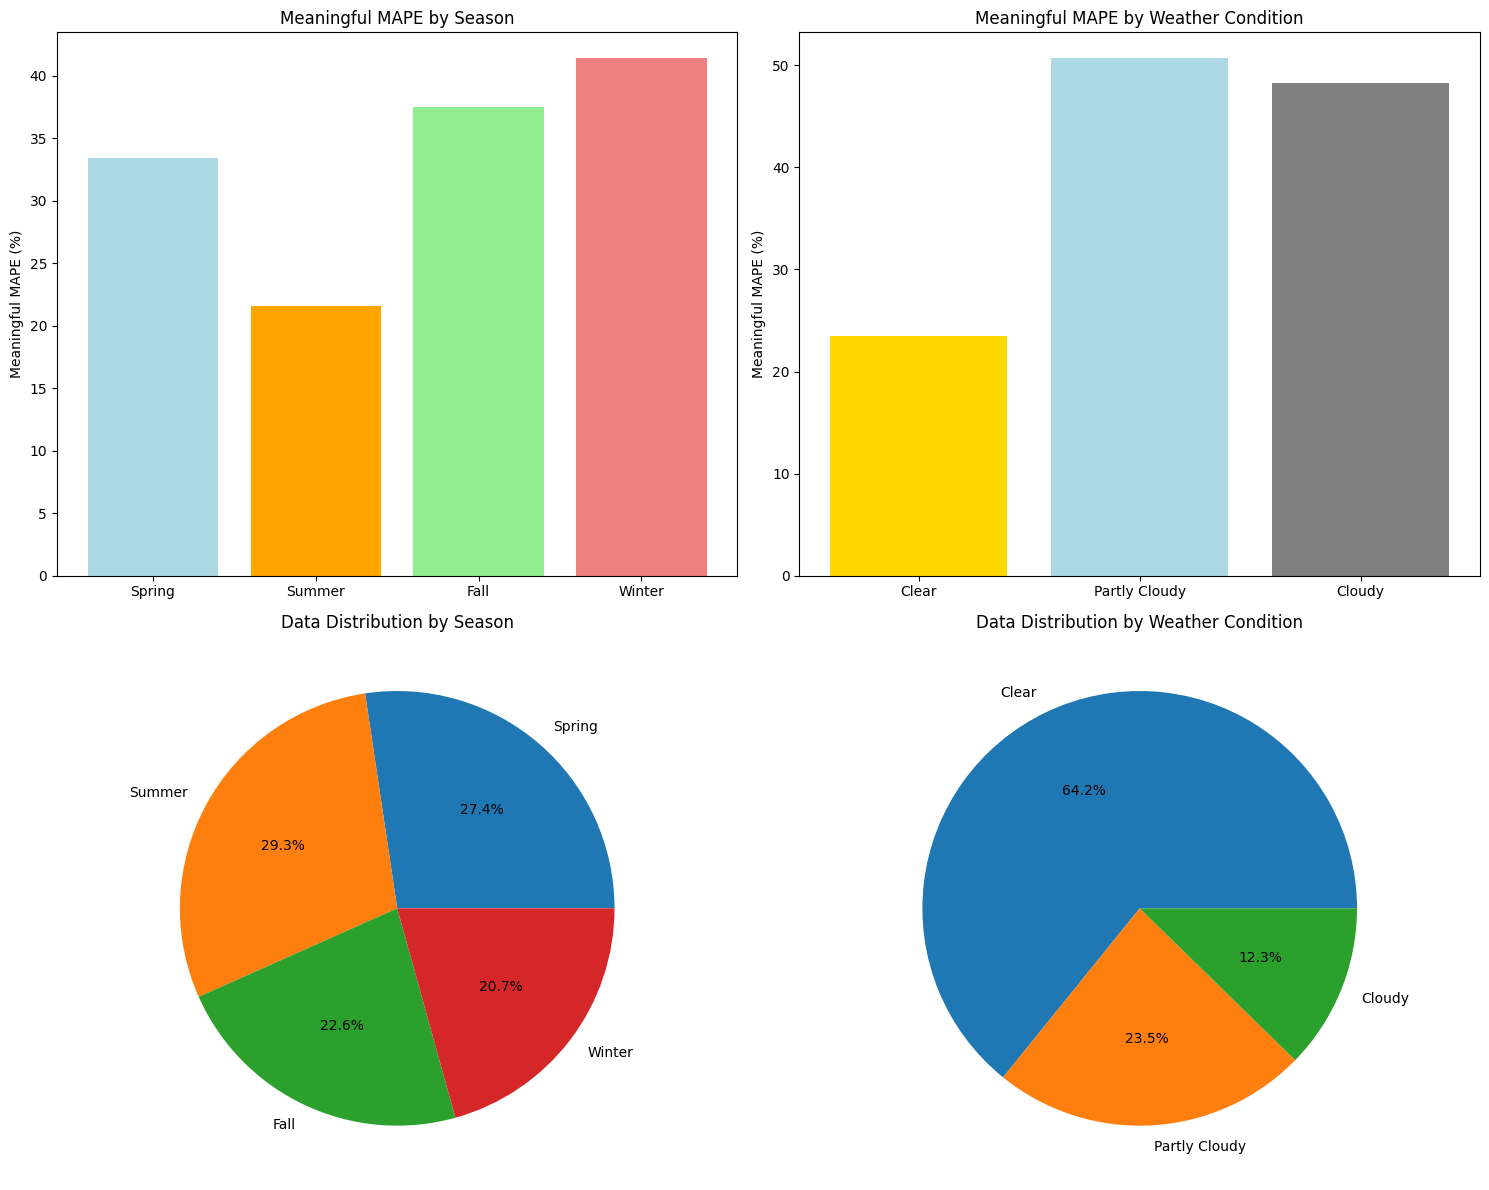

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ============================================================================
# 1. SEASONAL SPLIT ANALYSIS
# ============================================================================

def seasonal_analysis(combined_df, model, X_features, y_target):
    """Analyze model performance by season"""

    # Define seasons (Northern Hemisphere)
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:  # [9, 10, 11]
            return 'Fall'

    combined_df['season'] = combined_df['month'].apply(get_season)

    # Filter daytime data
    daytime_mask = (combined_df['Power'] > 0.1) & (combined_df['ghi'] > 10)
    daytime_data = combined_df[daytime_mask].copy()

    seasonal_results = []

    for season in ['Spring', 'Summer', 'Fall', 'Winter']:
        season_data = daytime_data[daytime_data['season'] == season]

        if len(season_data) > 100:  # Ensure sufficient data
            X_season = season_data[X_features]
            y_season = season_data[y_target]

            # Make predictions
            y_pred_season = model.predict(X_season)

            # Calculate metrics
            mae = mean_absolute_error(y_season, y_pred_season)
            r2 = r2_score(y_season, y_pred_season)

            # Meaningful MAPE (>1kW)
            meaningful_mask = y_season > 1.0
            if meaningful_mask.sum() > 0:
                meaningful_mape = np.mean(np.abs((y_season[meaningful_mask] - y_pred_season[meaningful_mask]) / y_season[meaningful_mask])) * 100
            else:
                meaningful_mape = float('inf')

            seasonal_results.append({
                'Season': season,
                'Samples': len(season_data),
                'MAE (kW)': round(mae, 3),
                'R²': round(r2, 3),
                'Meaningful MAPE (%)': f"{meaningful_mape:.1f}%",
                'Avg Power (kW)': round(y_season.mean(), 2),
                'Avg GHI (W/m²)': round(season_data['ghi'].mean(), 0)
            })

    return pd.DataFrame(seasonal_results)


#  WEATHER CONDITION ANALYSIS

def weather_condition_analysis(combined_df, model, X_features, y_target):
    """Analyze model performance by weather conditions"""

    # Filter daytime data
    daytime_mask = (combined_df['Power'] > 0.1) & (combined_df['ghi'] > 10)
    daytime_data = combined_df[daytime_mask].copy()

    # Define weather conditions
    def classify_weather(row):
        cloud_opacity = row['cloud_opacity']
        ghi = row['ghi']
        clearsky_ghi = row['clearsky_ghi']
        clearsky_index = ghi / (clearsky_ghi + 1)  # Avoid division by zero

        if cloud_opacity < 20 and clearsky_index > 0.8:
            return 'Clear'
        elif cloud_opacity > 70 or clearsky_index < 0.4:
            return 'Cloudy'
        else:
            return 'Partly Cloudy'

    daytime_data['weather_condition'] = daytime_data.apply(classify_weather, axis=1)

    weather_results = []

    for condition in ['Clear', 'Partly Cloudy', 'Cloudy']:
        condition_data = daytime_data[daytime_data['weather_condition'] == condition]

        if len(condition_data) > 50:  # Ensure sufficient data
            X_condition = condition_data[X_features]
            y_condition = condition_data[y_target]

            # Make predictions
            y_pred_condition = model.predict(X_condition)

            # Calculate metrics
            mae = mean_absolute_error(y_condition, y_pred_condition)
            r2 = r2_score(y_condition, y_pred_condition)

            # Meaningful MAPE (>1kW)
            meaningful_mask = y_condition > 1.0
            if meaningful_mask.sum() > 0:
                meaningful_mape = np.mean(np.abs((y_condition[meaningful_mask] - y_pred_condition[meaningful_mask]) / y_condition[meaningful_mask])) * 100
            else:
                meaningful_mape = float('inf')

            weather_results.append({
                'Weather Condition': condition,
                'Samples': len(condition_data),
                'MAE (kW)': round(mae, 3),
                'R²': round(r2, 3),
                'Meaningful MAPE (%)': f"{meaningful_mape:.1f}%",
                'Avg Power (kW)': round(y_condition.mean(), 2),
                'Avg Cloud Opacity (%)': round(condition_data['cloud_opacity'].mean(), 1),
                'Avg Clearsky Index': round(condition_data['clearsky_index'].mean(), 3)
            })

    return pd.DataFrame(weather_results)


def real_world_validation_framework():
    """Framework for testing on new location data"""

# Example usage with your best model (XGBoost)
print("=== SEASONAL ANALYSIS ===")
seasonal_results = seasonal_analysis(combined_df, xgb_model, feature_columns, 'Power')
print(seasonal_results.to_string(index=False))

print("\n=== WEATHER CONDITION ANALYSIS ===")
weather_results = weather_condition_analysis(combined_df, xgb_model, feature_columns, 'Power')
print(weather_results.to_string(index=False))

print("\n=== REAL-WORLD VALIDATION FRAMEWORK ===")
print(real_world_validation_framework())

# VISUALIZATION

def plot_performance_analysis():
    """Create visualizations for the analysis"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Seasonal performance
    seasonal_mae = [float(x.replace('%', '')) for x in seasonal_results['Meaningful MAPE (%)']] # FIX: Use Meaningful MAPE and remove '%'
    axes[0,0].bar(seasonal_results['Season'], seasonal_mae, color=['lightblue', 'orange', 'lightgreen', 'lightcoral'])
    axes[0,0].set_title('Meaningful MAPE by Season') # FIX: Update title
    axes[0,0].set_ylabel('Meaningful MAPE (%)') # FIX: Update label

    # Weather condition performance
    weather_mae = [float(x.replace('%', '')) for x in weather_results['Meaningful MAPE (%)']] # FIX: Use Meaningful MAPE and remove '%'
    axes[0,1].bar(weather_results['Weather Condition'], weather_mae, color=['gold', 'lightblue', 'gray'])
    axes[0,1].set_title('Meaningful MAPE by Weather Condition') # FIX: Update title
    axes[0,1].set_ylabel('Meaningful MAPE (%)') # FIX: Update label

    # Sample distribution by season
    axes[1,0].pie(seasonal_results['Samples'], labels=seasonal_results['Season'], autopct='%1.1f%%')
    axes[1,0].set_title('Data Distribution by Season')

    # Sample distribution by weather condition
    axes[1,1].pie(weather_results['Samples'], labels=weather_results['Weather Condition'], autopct='%1.1f%%')
    axes[1,1].set_title('Data Distribution by Weather Condition')

    plt.tight_layout()
    plt.show()

# Run visualization
plot_performance_analysis()